## Dependencias
# Ejecutar este comando para instalar las librerías necesarias
```
penv/Scripts/activate
pip install pandas numpy scikit-learn matplotlib seaborn jinja2
```

In [1]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd # Librería para la manipulación y el análisis de datos
import numpy as np # Librería para la manipulación de datos y para la ejecución de operaciones matemáticas
import matplotlib.pyplot as plt # Librería para la visualización de datos
import seaborn as sns # Librería para la visualización de datosr, MinMaxScaler, OrdinalEncoder # Librería para crear modelos de ML

In [2]:

# df_inicial1 = pd.read_csv("DatasetsTFM/customer_commercial_activity.csv")
# df_sample1 = df_inicial1.sample(10000).copy(deep=True)
# df_sample1.to_csv("DatasetsTFM/customer_commercial_activity_sample.csv", index=False)

In [3]:
# df_inicial2 = pd.read_csv("DatasetsTFM/customer_products.csv")
# df_sample2 = df_inicial2.sample(10000).copy(deep=True)
# df_sample2.to_csv("DatasetsTFM/customer_products_sample.csv", index=False)

In [4]:
# df_inicial3 = pd.read_csv("DatasetsTFM/customer_sociodemographics.csv")
# df_sample3 = df_inicial3.sample(10000).copy(deep=True)
# df_sample3.to_csv("DatasetsTFM/customer_sociodemographics_sample.csv", index=False)

In [5]:
# df_inicial4 = pd.read_csv("DatasetsTFM/product_description.csv")
# df_sample4 = df_inicial4.sample(13).copy(deep=True)
# df_sample4.to_csv("DatasetsTFM/product_description_sample.csv", index=False)

In [6]:
# df_inicial5 = pd.read_csv("DatasetsTFM/sales.csv")
# df_sample5 = df_inicial5.sample(10000).copy(deep=True)
# df_sample5.to_csv("DatasetsTFM/sales_sample.csv", index=False)

In [7]:
# 1. Cargar los datasets
df_prod = pd.read_csv("../DatasetsTFM/customer_products.csv")
df_socio = pd.read_csv("../DatasetsTFM/customer_sociodemographics.csv")
df_comm = pd.read_csv("../DatasetsTFM/customer_commercial_activity.csv")
df_sales = pd.read_csv("../DatasetsTFM/sales.csv")
df_prod_desc = pd.read_csv("../DatasetsTFM/product_description.csv")

In [8]:
duplicados = df_socio[df_socio.duplicated(subset=['pk_cid'], keep=False)]
duplicados.sort_values('pk_cid')

,Unnamed: 0,pk_cid,pk_partition,country_id,region_code,gender,age,deceased,salary
1479563,4078994,15891,2018-07,ES,28.0,H,59,N,NaN
2168122,5319232,15891,2018-08,ES,28.0,H,59,N,NaN
4876040,11171013,16063,2019-03,ES,28.0,H,62,N,NaN
4480637,10426151,16063,2019-02,ES,28.0,H,62,N,NaN
5523397,13026461,16063,2019-05,ES,28.0,H,62,N,NaN
...,...,...,...,...,...,...,...,...,...
5682990,13339892,1548204,2019-05,ES,8.0,V,54,N,NaN
5682989,13339891,1548206,2019-05,ES,28.0,H,40,N,NaN
5100677,11931730,1548206,2019-04,ES,28.0,H,40,N,NaN
5100678,11931731,1548207,2019-04,ES,8.0,V,32,N,NaN


In [25]:
# Agrupamos por cliente y contamos cuántos salarios DIFERENTES ha tenido
# dropna=False es importante: cuenta cambiar de NaN a un valor numérico como un cambio
conteo_cambios = df_socio.groupby('pk_cid')['salary'].nunique(dropna=False)

# Filtramos solo los que tienen más de 1 valor distinto
clientes_con_cambios = conteo_cambios[conteo_cambios > 1]

print(f"Hay {len(clientes_con_cambios)} clientes que han cambiado de salario (o de NaN a dato).")

Hay 65 clientes que han cambiado de salario (o de NaN a dato).


In [10]:
# Cogemos, por ejemplo, los primeros 5 clientes que sabemos que han cambiado
ids_ejemplo = clientes_con_cambios.head(5).index

# Filtramos el dataframe original solo con esos IDs y ordenamos para ver la historia
historial_cambios = df_socio[df_socio['pk_cid'].isin(ids_ejemplo)].sort_values(['pk_cid', 'pk_partition'])

# Mostramos las columnas relevantes
cols_interes = ['pk_cid', 'pk_partition', 'salary']
historial_cambios[cols_interes]

,pk_cid,pk_partition,salary
1477622,532488,2018-07,NaN
1842798,532488,2018-08,97220.64
2169035,532488,2018-09,97220.64
2945763,532488,2018-10,97220.64
2953820,532488,2018-11,97220.64
...,...,...,...
4196303,1017104,2019-01,NaN
4523606,1017104,2019-02,NaN
5019651,1017104,2019-03,NaN
5258610,1017104,2019-04,157753.62


In [24]:
conteo_cambios = df_comm.groupby('pk_cid')['segment'].nunique(dropna=False)

# Filtramos solo los que tienen más de 1 valor distinto
clientes_con_cambios = conteo_cambios[conteo_cambios > 1]

print(f"Hay {len(clientes_con_cambios)} clientes que han cambiado de segmento (o de NaN a dato).")

Hay 130295 clientes que han cambiado de segmento (o de NaN a dato).


In [12]:
# Cogemos, por ejemplo, los primeros 5 clientes que sabemos que han cambiado
ids_ejemplo = clientes_con_cambios.head(5).index

# Filtramos el dataframe original solo con esos IDs y ordenamos para ver la historia
historial_cambios = df_comm[df_comm['pk_cid'].isin(ids_ejemplo)].sort_values(['pk_cid', 'pk_partition'])

# Mostramos las columnas relevantes
cols_interes = ['pk_cid', 'pk_partition', 'segment']
historial_cambios[cols_interes]

,pk_cid,pk_partition,segment
1479563,15891,2018-07,NaN
2168122,15891,2018-08,02 - PARTICULARES
2962973,16063,2018-11,NaN
3628236,16063,2018-12,02 - PARTICULARES
4028169,16063,2019-01,02 - PARTICULARES
4480637,16063,2019-02,02 - PARTICULARES
4876040,16063,2019-03,02 - PARTICULARES
5134317,16063,2019-04,02 - PARTICULARES
5523397,16063,2019-05,02 - PARTICULARES
3628238,16203,2018-12,NaN


In [13]:
for i in df_comm.columns:
    prctj = df_comm[i].isnull().mean() * 100
    print(f'{prctj:.3f}% \tde nulos en {i}')

0.000% 	de nulos en Unnamed: 0
0.000% 	de nulos en pk_cid
0.000% 	de nulos en pk_partition
0.000% 	de nulos en entry_date
2.231% 	de nulos en entry_channel
0.000% 	de nulos en active_customer
2.246% 	de nulos en segment


In [14]:
for i in df_socio.columns:
    prctj = df_socio[i].isnull().mean() * 100
    print(f'{prctj:.3f}% \tde nulos en {i}')

0.000% 	de nulos en Unnamed: 0
0.000% 	de nulos en pk_cid
0.000% 	de nulos en pk_partition
0.000% 	de nulos en country_id
0.038% 	de nulos en region_code
0.000% 	de nulos en gender
0.000% 	de nulos en age
0.000% 	de nulos en deceased
25.845% 	de nulos en salary


In [15]:
print(df_socio['pk_partition'].dtype)
print(df_comm['pk_partition'].dtype)
print(df_socio['pk_cid'].dtype)
print(df_comm['pk_cid'].dtype)

object
object
int64
int64


In [16]:
def limpiar_columnas_basura(df):
    cols_to_drop = [c for c in df.columns if 'Unnamed' in c]
    if cols_to_drop:
        print(f"🗑️ Eliminando columnas basura: {cols_to_drop}")
        df.drop(columns=cols_to_drop, inplace=True)
    return df

In [17]:
df_prod = limpiar_columnas_basura(df_prod)
df_socio = limpiar_columnas_basura(df_socio)
df_comm = limpiar_columnas_basura(df_comm)
df_sales = limpiar_columnas_basura(df_sales)
df_prod_desc = limpiar_columnas_basura(df_prod_desc)

🗑️ Eliminando columnas basura: ['Unnamed: 0']
🗑️ Eliminando columnas basura: ['Unnamed: 0']
🗑️ Eliminando columnas basura: ['Unnamed: 0']
🗑️ Eliminando columnas basura: ['Unnamed: 0']
🗑️ Eliminando columnas basura: ['Unnamed: 0']


In [18]:
df_prod_desc.head(13)

,pk_product_ID,product_desc,family_product
0,4657,em_acount,account
1,3819,debit_card,payment_card
2,1364,pension_plan,pension_plan
3,2234,payroll,account
4,2235,payroll_account,account
5,8871,emc_account,account
6,2312,credit_card,payment_card
7,2335,short_term_deposit,investment
8,2336,long_term_deposit,investment
9,2673,securities,investment


In [19]:
# SQL Equivalente:
# SELECT s.*, d.product_desc 
# FROM sales s 
# LEFT JOIN product_description d ON s.product_ID = d.pk_product_ID;

# En Pandas:
df_ventas_enriquecida = pd.merge(
    df_sales, 
    df_prod_desc, 
    left_on='product_ID', 
    right_on='pk_product_ID', 
    how='left'
)
# df_ventas_enriquecida = limpiar_columnas_basura(df_ventas_enriquecida)
df_ventas_enriquecida.head(20)
#df_ventas_enriquecida["Unnamed: 0_y"].value_counts()

,pk_sale,cid,month_sale,product_ID,net_margin,pk_product_ID,product_desc,family_product
0,6666,33620,2018-05-01,2335,952.9,2335,short_term_deposit,investment
1,6667,35063,2018-06-01,2335,1625.2,2335,short_term_deposit,investment
2,6668,37299,2018-02-01,2335,1279.7,2335,short_term_deposit,investment
3,6669,39997,2018-02-01,2335,1511.9,2335,short_term_deposit,investment
4,6670,44012,2018-02-01,2335,1680.3,2335,short_term_deposit,investment
5,6671,66770,2018-06-01,2335,1772.0,2335,short_term_deposit,investment
6,6672,100296,2018-04-01,2335,1391.9,2335,short_term_deposit,investment
7,6673,101658,2018-08-01,2335,1466.7,2335,short_term_deposit,investment
8,6674,114080,2018-03-01,2335,1772.9,2335,short_term_deposit,investment
9,6675,124554,2018-10-01,2335,1534.5,2335,short_term_deposit,investment


In [20]:
import polars as pl
import pyarrow

# 1. Convertir a Polars (requiere pyarrow instalado)
df_socio_pl = pl.from_pandas(df_socio)
df_comm_pl = pl.from_pandas(df_comm) 

# 2. Ejecutar el join usando las variables de Polars (_pl)
df_master_pl = df_socio_pl.join(
    df_comm_pl,
    on=['pk_cid', 'pk_partition'],
    how='inner',
    validate='1:1'
)

# Opcional: Si necesitas volver a pandas al final
# df_master = df_master_pl.to_pandas()

In [21]:
# SQL Equivalente:
# SELECT * FROM sociodemo s
# JOIN commercial c ON s.pk_cid = c.pk_cid AND s.pk_partition = c.pk_partition

# En Pandas:
df_master = pd.merge(
    df_socio,
    df_comm,
    on=['pk_cid', 'pk_partition'],
    how='inner',
    validate='1:1'
)
# df_master = limpiar_columnas_basura(df_master)
df_master.head(20)
# df_master["em_acount"].value_counts()
print(f"Hay {len(df_master)} tantos inner")
print(f"Hay {len(df_socio)} tantos socio")
print(f"Hay {len(df_comm)} tantos customer comercial activity")

Hay 5962924 tantos inner
Hay 5962924 tantos socio
Hay 5962924 tantos customer comercial activity


In [22]:
df_master.columns

Index(['pk_cid', 'pk_partition', 'country_id', 'region_code', 'gender', 'age',
       'deceased', 'salary', 'entry_date', 'entry_channel', 'active_customer',
       'segment'],
      dtype='object')

In [ ]:
target = 'salary'
cols_group = ['segment', 'gender']

stats = df_master.groupby(cols_group)[target].agg(['mean', 'count'])
stats_filtered = stats[stats['count'] > 1000].sort_values(by='mean', ascending=False)
stats_filtered

mean    count
segment            gender                        
01 - TOP           H       161520.400057    31754
                   V       138741.053631    43638
03 - UNIVERSITARIO V       118237.359537  1294538
02 - PARTICULARES  H       117063.183064   588927
                   V       113710.202089   784486
03 - UNIVERSITARIO H       112410.515101  1643141

In [ ]:
df_master

,pk_cid,pk_partition,country_id,region_code,gender,age,deceased,salary,entry_date,entry_channel,active_customer,segment
0,1375586,2018-01,ES,29.0,H,35,N,87218.10,2018-01,KHL,1.0,02 - PARTICULARES
1,1050611,2018-01,ES,13.0,V,23,N,35548.74,2015-08,KHE,0.0,03 - UNIVERSITARIO
2,1050612,2018-01,ES,13.0,V,23,N,122179.11,2015-08,KHE,0.0,03 - UNIVERSITARIO
3,1050613,2018-01,ES,50.0,H,22,N,119775.54,2015-08,KHD,0.0,03 - UNIVERSITARIO
4,1050614,2018-01,ES,50.0,V,23,N,NaN,2015-08,KHE,1.0,03 - UNIVERSITARIO
...,...,...,...,...,...,...,...,...,...,...,...,...
5962919,1166765,2019-05,ES,50.0,V,22,N,43912.17,2016-08,KHE,0.0,03 - UNIVERSITARIO
5962920,1166764,2019-05,ES,26.0,V,23,N,23334.99,2016-08,KHE,0.0,03 - UNIVERSITARIO
5962921,1166763,2019-05,ES,50.0,H,47,N,NaN,2016-08,KHE,1.0,02 - PARTICULARES
5962922,1166789,2019-05,ES,50.0,H,22,N,199592.82,2016-08,KHE,0.0,03 - UNIVERSITARIO


In [ ]:
df_test = df_master.copy()
df_test.loc[df_test['country_id'] != 'ES', 'country_id'] = 'international'
df_test = df_test[df_test['country_id'] == 'ES']
for i in df_test.columns:
    prctj = df_test[i].isnull().sum()
    print(f'{prctj} \tde nulos en {i}')

0 	de nulos en pk_cid
0 	de nulos en pk_partition
0 	de nulos en country_id
12 	de nulos en region_code
25 	de nulos en gender
0 	de nulos en age
0 	de nulos en deceased
1538889 	de nulos en salary
0 	de nulos en entry_date
133019 	de nulos en entry_channel
0 	de nulos en active_customer
133932 	de nulos en segment


In [ ]:
for i in df_socio.columns:
    prctj = df_socio[i].isnull().mean()*100
    print(f'{prctj} \tde nulos en {i}')

0.0 	de nulos en pk_cid
0.0 	de nulos en pk_partition
0.0 	de nulos en country_id
0.03796794995207049 	de nulos en region_code
0.0004192573978806371 	de nulos en gender
0.0 	de nulos en age
0.0 	de nulos en deceased
25.844770116137656 	de nulos en salary


In [ ]:
for i in df_master.columns:
    prctj = df_master[i].isnull().sum()
    print(f'{prctj} \tde nulos en {i}')

0 	de nulos en pk_cid
0 	de nulos en pk_partition
0 	de nulos en country_id
2264 	de nulos en region_code
25 	de nulos en gender
0 	de nulos en age
0 	de nulos en deceased
1541104 	de nulos en salary
0 	de nulos en entry_date
133033 	de nulos en entry_channel
0 	de nulos en active_customer
133944 	de nulos en segment


In [ ]:
for i in df_comm.columns:
    prctj = df_comm[i].isnull().sum()
    print(f'{prctj} \tde nulos en {i}')

0 	de nulos en pk_cid
0 	de nulos en pk_partition
0 	de nulos en entry_date
133033 	de nulos en entry_channel
0 	de nulos en active_customer
133944 	de nulos en segment


In [ ]:
df_prod_desc['family_product'].value_counts()

family_product
account         4
investment      4
payment_card    2
loan            2
pension_plan    1
Name: count, dtype: int64

In [ ]:
df_master[(df_master['country_id'] == 'ES')]['region_code'].value_counts().shape

(52,)

In [ ]:
df_master.head(1)

,pk_cid,pk_partition,country_id,region_code,gender,age,deceased,salary,entry_date,entry_channel,active_customer,segment
0,1375586,2018-01,ES,29.0,H,35,N,87218.1,2018-01,KHL,1.0,02 - PARTICULARES


In [ ]:
import sys
import os
import importlib

# Obtiene la ruta absoluta del directorio actual del script
# current_dir = os.path.dirname(os.path.abspath(__file__))  # python
current_dir = os.getcwd()                                   # jupyter notebook

# Obtiene la ruta al directorio 'src' (subiendo un nivel y entrando a src)
src_path = os.path.join(current_dir, '..', 'src')

# Lo añade al path de Python
sys.path.append(src_path)

# Ahora ya puedes importar
import utils
importlib.reload(utils)  # Forzar recarga si ya se había importado antes

df_inicial_test_2 = df_prod.copy()

null = utils.auditoria_nulos(df_inicial_test_2)

df_inicial_test_knn = df_inicial_test_2.copy()

target_equipamiento = ['aire_acondicionado', 'camara_trasera', 'elevalunas_electrico', 
                       'bluetooth', 'alerta_lim_velocidad', 'volante_regulable']
target_estructural = ['modelo', 'tipo_coche', 'tipo_gasolina']
target_fechas = ['fecha_registro', 'fecha_venta'] # A estos les aplicaremos mediana

config_strict = {'potencia': 0.01, 'km': 0.10}


for col in target_equipamiento:
    df_inicial_test_knn = utils.imputar_por_similitud(
        df_inicial_test_knn, target_col=col, numeric_cols=config_strict,
        cat_bool_cols=['modelo', 'tipo_gasolina', 'tipo_coche'],
        umbral_dominancia=0.70, estrategia='moda' # MODA para equipamiento
    )

for col in target_estructural:
    preds = [c for c in target_estructural if c != col]
    df_inicial_test_knn = utils.imputar_por_similitud(
        df_inicial_test_knn, target_col=col, numeric_cols=config_strict,
        cat_bool_cols=preds, umbral_dominancia=0.70, estrategia='moda' # MODA para categóricas
    )

config_relaxed = {'potencia': 0.01, 'km': 0.30}

for _ in range(2): 
    for col in target_estructural:
        preds = [c for c in target_estructural if c != col]
        df_inicial_test_knn = utils.imputar_por_similitud(
            df_inicial_test_knn, target_col=col, numeric_cols=config_relaxed,
            cat_bool_cols=preds, umbral_dominancia=0.50, estrategia='moda'
        )

for col in target_equipamiento:
    df_inicial_test_knn = utils.imputar_por_similitud(
        df_inicial_test_knn, target_col=col, numeric_cols=config_relaxed,
        cat_bool_cols=['modelo', 'tipo_coche'], umbral_dominancia=0.55, estrategia='moda'
    )




# df_limpio = df_inicial_test_knn[df_inicial_test_knn.isnull().sum(axis=1) <= 1].copy()
display(utils.auditoria_nulos(df_inicial_test_knn))

Auditoría de nulos en el DataFrame:
Columnas afectadas:
payroll         61
pension_plan    61
dtype: int64

Total de filas con algún dato faltante: 61 (0.00% del total)

Distribución de gravedad (¿Cuántos datos faltan por fila?):


n_nulos
2    61
Name: count, dtype: int64


Ejemplo de filas con múltiples nulos (Top 5):


,pk_cid,pk_partition,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount,n_nulos
20679,1023793,2018-01,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,2
45769,1097831,2018-01,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,2
51586,1132935,2018-01,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,2
56072,1118340,2018-01,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,2
102989,1266281,2018-01,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,2



KeyboardInterrupt



In [ ]:
for i in df_master.columns:
    prctj = df_master[i].isnull().mean() * 100
    print(f'{prctj:.3f}% \tde nulos en {i}')

0.000% 	de nulos en pk_cid
0.000% 	de nulos en pk_partition
0.000% 	de nulos en country_id
0.038% 	de nulos en region_code
0.000% 	de nulos en gender
0.000% 	de nulos en age
0.000% 	de nulos en deceased
25.845% 	de nulos en salary
0.000% 	de nulos en entry_date
2.231% 	de nulos en entry_channel
0.000% 	de nulos en active_customer
2.246% 	de nulos en segment


In [ ]:
def calcular_nuevas_ventas(df_completo, columna_producto):
    """
    Calcula las ventas (cambio de 0 a 1) asegurando que comparamos
    al MISMO cliente en meses CONSECUTIVOS.
    """
    # 1. Ordenamos para garantizar el orden cronológico
    df_sorted = df_completo.sort_values(by=['pk_cid', 'pk_partition'])
    
    # 2. Agrupamos por cliente antes de hacer el shift (EL PASO CLAVE QUE FALTABA)
    # Esto evita que compares el último mes del Cliente A con el primero del Cliente B
    df_sorted['estado_anterior'] = df_sorted.groupby('pk_cid')[columna_producto].shift(1)
    
    # 3. Rellenamos los nulos (el primer mes de cada cliente) con 0
    df_sorted['estado_anterior'] = df_sorted['estado_anterior'].fillna(0)
    
    # 4. Calculamos la venta: Tiene ahora (1) Y NO tenía antes (0)
    # OJO: Convertimos a entero para evitar problemas de float
    mascara_venta = (df_sorted[columna_producto] == 1) & (df_sorted['estado_anterior'] == 0)
    
    # 5. Filtramos solo las ventas
    ventas = df_sorted[mascara_venta]
    
    return ventas

# PRUEBA FINAL CON EL DATASET COMPLETO (No con la muestra, que tiene huecos)
df_ventas_tarjetas = calcular_nuevas_ventas(df_prod, 'credit_card')
df_ventas_tarjetas = limpiar_columnas_basura(df_ventas_tarjetas)
print(f"Ventas detectadas con tarjeta de crédito: {len(df_ventas_tarjetas)}")
df_ventas_tarjetas.head(10)

Ventas detectadas con tarjeta de crédito: 14491


,pk_cid,pk_partition,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount,estado_anterior
237922,19021,2018-01,0,0,0,0,0,0,0,1,0.0,0.0,0,0,0,0,0,0.0
5523391,19021,2019-05,0,0,0,0,0,0,0,1,0.0,0.0,0,0,0,0,0,0.0
729009,20333,2018-04,0,0,0,0,0,0,0,1,0.0,0.0,0,0,1,0,1,0.0
3628234,20333,2018-12,0,0,0,0,0,0,0,1,0.0,0.0,0,0,1,0,1,0.0
5134242,20333,2019-04,0,0,0,0,0,0,0,1,0.0,0.0,0,0,1,0,1,0.0
728991,29008,2018-04,0,0,0,0,0,0,0,1,0.0,0.0,0,0,0,0,1,0.0
2943647,29896,2018-10,0,0,0,0,0,0,0,1,0.0,0.0,0,0,0,0,0,0.0
241192,31825,2018-02,0,0,0,0,0,1,0,1,0.0,0.0,0,0,0,0,0,0.0
2943578,31825,2018-10,0,0,0,0,0,1,0,1,0.0,0.0,0,0,0,0,0,0.0
3628174,31825,2018-12,0,0,0,0,0,0,0,1,0.0,0.0,0,0,0,0,0,0.0


In [ ]:
df_prod.sample(20)
#df_prod["short_term_deposit"].value_counts()
#for col in df_prod.columns:
#    print(f"{col}: {df_prod[col].nunique()} valores únicos")

,pk_cid,pk_partition,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount
2097176,1193029,2018-08,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
3443679,1258689,2018-12,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0
4109347,1136980,2019-01,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0
5718931,1413079,2019-05,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
1477070,722544,2018-07,0,0,0,0,0,0,0,0,0.0,0.0,0,1,0,0,0
343930,1380344,2018-02,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
4812716,1267429,2019-03,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
4229561,1300958,2019-02,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
3404205,1088148,2018-12,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
3365409,1016573,2018-12,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0


In [ ]:
df_prod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5962924 entries, 0 to 5962923
Data columns (total 17 columns):
 #   Column              Dtype  
---  ------              -----  
 0   pk_cid              int64  
 1   pk_partition        object 
 2   short_term_deposit  int64  
 3   loans               int64  
 4   mortgage            int64  
 5   funds               int64  
 6   securities          int64  
 7   long_term_deposit   int64  
 8   em_account_pp       int64  
 9   credit_card         int64  
 10  payroll             float64
 11  pension_plan        float64
 12  payroll_account     int64  
 13  emc_account         int64  
 14  debit_card          int64  
 15  em_account_p        int64  
 16  em_acount           int64  
dtypes: float64(2), int64(14), object(1)
memory usage: 773.4+ MB


In [ ]:
df_comm.head(20)

,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment
0,1375586,2018-01,2018-01,KHL,1.0,02 - PARTICULARES
1,1050611,2018-01,2015-08,KHE,0.0,03 - UNIVERSITARIO
2,1050612,2018-01,2015-08,KHE,0.0,03 - UNIVERSITARIO
3,1050613,2018-01,2015-08,KHD,0.0,03 - UNIVERSITARIO
4,1050614,2018-01,2015-08,KHE,1.0,03 - UNIVERSITARIO
5,1050615,2018-01,2015-08,KHE,0.0,03 - UNIVERSITARIO
6,1050616,2018-01,2015-08,KHE,0.0,03 - UNIVERSITARIO
7,1050617,2018-01,2015-08,KHE,1.0,03 - UNIVERSITARIO
8,1050619,2018-01,2015-08,KHE,0.0,03 - UNIVERSITARIO
9,1050620,2018-01,2015-08,KHE,0.0,03 - UNIVERSITARIO


In [ ]:
df_socio.head(20)
#df_socio[""].value_counts()

,pk_cid,pk_partition,country_id,region_code,gender,age,deceased,salary
0,1375586,2018-01,ES,29.0,H,35,N,87218.10
1,1050611,2018-01,ES,13.0,V,23,N,35548.74
2,1050612,2018-01,ES,13.0,V,23,N,122179.11
3,1050613,2018-01,ES,50.0,H,22,N,119775.54
4,1050614,2018-01,ES,50.0,V,23,N,NaN
5,1050615,2018-01,ES,45.0,H,23,N,22220.04
6,1050616,2018-01,ES,24.0,H,23,N,295590.36
7,1050617,2018-01,ES,50.0,H,23,N,113316.66
8,1050619,2018-01,ES,20.0,H,24,N,NaN
9,1050620,2018-01,ES,10.0,H,23,N,113194.98


In [ ]:
# 2. Convertir la partición a fecha real para poder ordenar correctamente
# Esto es CRÍTICO: Sin orden temporal, no podemos calcular ventas
for df in [df_prod, df_socio, df_comm]:
    df['pk_partition'] = pd.to_datetime(df['pk_partition'])

print("Datos cargados. Rango de fechas en la muestra:")
print(f"Desde {df_prod['pk_partition'].min()} hasta {df_prod['pk_partition'].max()}")

Datos cargados. Rango de fechas en la muestra:
Desde 2018-01-01 00:00:00 hasta 2019-05-01 00:00:00


In [ ]:
# Seleccionamos un cliente que tenga bastante historia en la muestra
# (Buscamos el ID que más veces se repite en el dataset de productos)
cliente_ejemplo = df_prod['pk_cid'].value_counts().idxmax()

print(f"Analizando al cliente ID: {cliente_ejemplo}")

# Filtramos su historia en la tabla de productos
historia_cliente = df_prod[df_prod['pk_cid'] == cliente_ejemplo].sort_values('pk_partition')

# Mostramos solo las columnas clave para no saturar
cols_visualizar = ['pk_cid', 'pk_partition', 'loans', 'credit_card', 'payroll']
display(historia_cliente[cols_visualizar])

Analizando al cliente ID: 538227


,pk_cid,pk_partition,loans,credit_card,payroll
239492,538227,2018-01-01,0,0,0.0
239513,538227,2018-02-01,0,0,0.0
482168,538227,2018-03-01,0,0,0.0
727294,538227,2018-04-01,0,0,0.0
1224628,538227,2018-05-01,0,0,0.0
1476624,538227,2018-06-01,0,0,0.0
1477561,538227,2018-07-01,0,0,0.0
1842771,538227,2018-08-01,0,0,0.0
2169116,538227,2018-09-01,0,0,0.0
2945664,538227,2018-10-01,0,0,0.0


In [ ]:
df_socio.head()

,pk_cid,pk_partition,country_id,region_code,gender,age,deceased,salary
0,1375586,2018-01-01,ES,29.0,H,35,N,87218.10
1,1050611,2018-01-01,ES,13.0,V,23,N,35548.74
2,1050612,2018-01-01,ES,13.0,V,23,N,122179.11
3,1050613,2018-01-01,ES,50.0,H,22,N,119775.54
4,1050614,2018-01-01,ES,50.0,V,23,N,NaN


In [ ]:
df_socio["deceased"].value_counts()

deceased
N    5961849
S       1075
Name: count, dtype: int64

In [ ]:
df_socio["country_id"].value_counts()

country_id
ES    5960672
GB        441
FR        225
DE        199
US        195
CH        194
BR         87
BE         81
VE         79
IE         68
MX         58
AT         51
AR         51
PL         49
IT         45
MA         34
CL         30
CN         28
CA         22
GA         17
DO         17
CO         17
RU         17
NO         17
GT         17
SN         17
MR         17
ET         17
CM         17
SA         17
CI         17
QA         17
LU         17
SE         16
DJ         11
PT         11
JM         11
RO          9
HU          8
DZ          7
PE          4
Name: count, dtype: int64

In [ ]:
df_comm.head()

,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment
0,1375586,2018-01-01,2018-01,KHL,1.0,02 - PARTICULARES
1,1050611,2018-01-01,2015-08,KHE,0.0,03 - UNIVERSITARIO
2,1050612,2018-01-01,2015-08,KHE,0.0,03 - UNIVERSITARIO
3,1050613,2018-01-01,2015-08,KHD,0.0,03 - UNIVERSITARIO
4,1050614,2018-01-01,2015-08,KHE,1.0,03 - UNIVERSITARIO


In [ ]:
# Vamos a unir la info comercial y sociodemográfica a nuestra tabla de productos
# La llave de unión es ['pk_cid', 'pk_partition']

vista_360 = pd.merge(
    historia_cliente,
    df_socio[['pk_cid', 'pk_partition', 'age', 'salary']], # Solo traemos edad y salario
    on=['pk_cid', 'pk_partition'],
    how='left'
)

vista_360 = pd.merge(
    vista_360,
    df_comm[['pk_cid', 'pk_partition', 'segment', 'active_customer']], # Traemos segmento y actividad
    on=['pk_cid', 'pk_partition'],
    how='left'
)

# Visualizamos cómo cambia el cliente mes a mes en todas sus dimensiones
cols_360 = ['pk_partition', 'loans', 'age', 'salary', 'segment', 'active_customer']
display(vista_360[cols_360])

,pk_partition,loans,age,salary,segment,active_customer
0,2018-01-01,0,30,70121.34,03 - UNIVERSITARIO,1.0
1,2018-02-01,0,30,70121.34,03 - UNIVERSITARIO,1.0
2,2018-03-01,0,30,70121.34,03 - UNIVERSITARIO,1.0
3,2018-04-01,0,30,70121.34,03 - UNIVERSITARIO,1.0
4,2018-05-01,0,30,70121.34,03 - UNIVERSITARIO,1.0
5,2018-06-01,0,30,70121.34,03 - UNIVERSITARIO,1.0
6,2018-07-01,0,30,70121.34,03 - UNIVERSITARIO,1.0
7,2018-08-01,0,30,70121.34,03 - UNIVERSITARIO,1.0
8,2018-09-01,0,30,70121.34,03 - UNIVERSITARIO,1.0
9,2018-10-01,0,30,70121.34,03 - UNIVERSITARIO,1.0


In [ ]:
# Vamos a enfocarnos en un producto, por ejemplo 'credit_card' (o cambia por 'loans' o 'payroll')
producto_analizar = 'credit_card' # Puedes cambiar esto por otro producto que tenga el cliente

# 1. Estado Actual (Lo que tiene en el mes T)
df_analisis = historia_cliente[['pk_cid', 'pk_partition', producto_analizar]].copy()
df_analisis = df_analisis.sort_values('pk_partition')

# 2. Estado Anterior (Lo que tenía en el mes T-1)
# Usamos .shift(1) para "bajar" los datos una fila
df_analisis['estado_mes_anterior'] = df_analisis[producto_analizar].shift(1).fillna(0)

# 3. Cálculo de la DIFERENCIA (Venta vs Baja vs Mantenimiento)
# 1 - 0 =  1 (Alta/Venta) -> ESTO ES LO QUE BUSCA CAROL
# 1 - 1 =  0 (Mantiene)
# 0 - 1 = -1 (Baja/Churn)
# 0 - 0 =  0 (Nada)
df_analisis['diferencia'] = df_analisis[producto_analizar] - df_analisis['estado_mes_anterior']

# 4. Etiquetamos para que sea legible a humanos
def etiquetar_venta(valor):
    if valor == 1: return "💰 NUEVA VENTA"
    if valor == -1: return "📉 BAJA"
    if valor == 0: return "Mantiene"
    
df_analisis['que_paso'] = df_analisis['diferencia'].apply(etiquetar_venta)

# Mostramos el resultado visual
# Busca las filas donde aparezca "NUEVA VENTA"
display(df_analisis)
# Filtramos solo las filas con nuevas ventas
nuevas_ventas = df_analisis[df_analisis['diferencia'] == 1]
print(f"Nuevas ventas encontradas: {len(nuevas_ventas)}")
display(nuevas_ventas)

,pk_cid,pk_partition,credit_card,estado_mes_anterior,diferencia,que_paso
239492,538227,2018-01-01,0,0.0,0.0,Mantiene
239513,538227,2018-02-01,0,0.0,0.0,Mantiene
482168,538227,2018-03-01,0,0.0,0.0,Mantiene
727294,538227,2018-04-01,0,0.0,0.0,Mantiene
1224628,538227,2018-05-01,0,0.0,0.0,Mantiene
1476624,538227,2018-06-01,0,0.0,0.0,Mantiene
1477561,538227,2018-07-01,0,0.0,0.0,Mantiene
1842771,538227,2018-08-01,0,0.0,0.0,Mantiene
2169116,538227,2018-09-01,0,0.0,0.0,Mantiene
2945664,538227,2018-10-01,0,0.0,0.0,Mantiene


Nuevas ventas encontradas: 0


,pk_cid,pk_partition,credit_card,estado_mes_anterior,diferencia,que_paso


In [ ]:
if 'pk_product_ID' in df_ventas_enriquecida.columns:
    df_ventas_enriquecida.drop(columns=['pk_product_ID'], inplace=True)

In [ ]:
filas_con_nulos = df_ventas_enriquecida[df_ventas_enriquecida['product_desc'].isnull()]
if len(filas_con_nulos) > 0:
    print(f"⚠️ ALERTA: Hay {len(filas_con_nulos)} ventas con IDs de producto desconocidos.")
    print("IDs de producto que no tienen descripción:")
    print(filas_con_nulos['product_ID'].unique())
    display(filas_con_nulos.head())
else:
    print("✅ Integridad perfecta: Todas las ventas tienen una descripción de producto asociada.")

✅ Integridad perfecta: Todas las ventas tienen una descripción de producto asociada.


In [ ]:
cols_productos = [col for col in df_prod.columns if col not in ['pk_cid', 'pk_partition']]

In [ ]:
def auditoria_nulos_inteligente(df):
    nulos_por_col = df.isnull().sum()
    cols_con_nulos = nulos_por_col[nulos_por_col > 0]
    
    if cols_con_nulos.empty:
        print("No hay nulos en este DataFrame.")
        return
    
    print(f"Columnas afectadas:\n{cols_con_nulos.sort_values(ascending=False)}")
    
    # Creamos una máscara para ver solo las filas que tienen AL MENOS un nulo
    filas_nulas = df[df.isnull().any(axis=1)].copy()
    
    # ¿Falta solo un dato o faltan 5 a la vez?
    filas_nulas['n_nulos'] = filas_nulas.isnull().sum(axis=1)
    
    print(f"\nTotal de filas con algún dato faltante: {len(filas_nulas)} ({(len(filas_nulas)/len(df))*100:.2f}% del total)")
    print("\nDistribución de gravedad (¿Cuántos datos faltan por fila?):")
    display(filas_nulas['n_nulos'].value_counts().sort_index())
    
    print("\nEjemplo de filas con múltiples nulos (Top 5):")
    display(filas_nulas.sort_values('n_nulos', ascending=False).head(5))
    
    return filas_nulas

In [ ]:
df_nulos_master = auditoria_nulos_inteligente(df_master)

Columnas afectadas:
salary           1541104
segment           133944
entry_channel     133033
region_code         2264
gender                25
dtype: int64

Total de filas con algún dato faltante: 1576663 (26.44% del total)

Distribución de gravedad (¿Cuántos datos faltan por fila?):


n_nulos
1    1440537
2      38557
3      97557
4         12
Name: count, dtype: int64


Ejemplo de filas con múltiples nulos (Top 5):


,pk_cid,pk_partition,country_id,region_code,gender,age,deceased,salary,entry_date,entry_channel,active_customer,segment,n_nulos
2753752,1376452,2018-10,HU,NaN,V,40,N,NaN,2018-01,NaN,0.0,NaN,4
1807232,1404475,2018-07,GB,NaN,H,52,N,NaN,2018-07,NaN,1.0,NaN,4
5097292,1544346,2019-04,FR,NaN,H,46,N,NaN,2019-04,NaN,1.0,NaN,4
2497030,1442391,2018-09,PL,NaN,V,37,N,NaN,2018-09,NaN,0.0,NaN,4
3679328,1516177,2018-12,AR,NaN,V,40,N,NaN,2018-12,NaN,1.0,NaN,4


In [ ]:
df_nulos_master = auditoria_nulos_inteligente(df_prod)

Columnas afectadas:
payroll         61
pension_plan    61
dtype: int64

Total de filas con algún dato faltante: 61 (0.00% del total)

Distribución de gravedad (¿Cuántos datos faltan por fila?):


n_nulos
2    61
Name: count, dtype: int64


Ejemplo de filas con múltiples nulos (Top 5):


,pk_cid,pk_partition,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount,n_nulos
20679,1023793,2018-01-01,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,2
45769,1097831,2018-01-01,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,2
51586,1132935,2018-01-01,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,2
56072,1118340,2018-01-01,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,2
102989,1266281,2018-01-01,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,2


In [ ]:
df_nulos_master = auditoria_nulos_inteligente(df_ventas_enriquecida)

No hay nulos en este DataFrame.


El salario puede estar asociado a la actividad (si no es activo no nos interesa y podemos poner 0), también al segmento (sacamos el promedio por segmento, país, región y ventanas de edad) y si está vivo o muerto.
El segmento lo ponemos como desconocido (podría ser moda)
El canal de entrada Desconocido (pueden tener correlación o ser datos migrados de bases de datos más viejas)
La región la podemos poner por moda según segmento (los universitarios tienden a estar en las mismas ciudades), edad y país
El género en sí mismo no sabría como rellenarlo, quizá como Desconocido o por moda si es muy claro, si son casos muy típicos quizá sería posible hasta eliminarlos

In [ ]:
df_nulos_ventas = auditoria_nulos_inteligente(df_ventas_enriquecida)

No hay nulos en este DataFrame.


In [ ]:
df_nulos_prod = auditoria_nulos_inteligente(df_prod)

Columnas afectadas:
payroll         61
pension_plan    61
dtype: int64

Total de filas con algún dato faltante: 61 (0.00% del total)

Distribución de gravedad (¿Cuántos datos faltan por fila?):


n_nulos
2    61
Name: count, dtype: int64


Ejemplo de filas con múltiples nulos (Top 5):


,pk_cid,pk_partition,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount,n_nulos
20679,1023793,2018-01-01,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,2
45769,1097831,2018-01-01,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,2
51586,1132935,2018-01-01,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,2
56072,1118340,2018-01-01,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,2
102989,1266281,2018-01-01,0,0,0,0,0,0,0,0,NaN,NaN,0,0,0,0,0,2


In [ ]:
df_prod.head(20)

,pk_cid,pk_partition,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount
0,1375586,2018-01-01,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
1,1050611,2018-01-01,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
2,1050612,2018-01-01,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
3,1050613,2018-01-01,1,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,0
4,1050614,2018-01-01,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
5,1050615,2018-01-01,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
6,1050616,2018-01-01,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
7,1050617,2018-01-01,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
8,1050619,2018-01-01,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1
9,1050620,2018-01-01,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,1


In [ ]:
df_prod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5962924 entries, 0 to 5962923
Data columns (total 17 columns):
 #   Column              Dtype         
---  ------              -----         
 0   pk_cid              int64         
 1   pk_partition        datetime64[ns]
 2   short_term_deposit  int64         
 3   loans               int64         
 4   mortgage            int64         
 5   funds               int64         
 6   securities          int64         
 7   long_term_deposit   int64         
 8   em_account_pp       int64         
 9   credit_card         int64         
 10  payroll             float64       
 11  pension_plan        float64       
 12  payroll_account     int64         
 13  emc_account         int64         
 14  debit_card          int64         
 15  em_account_p        int64         
 16  em_acount           int64         
dtypes: datetime64[ns](1), float64(2), int64(14)
memory usage: 773.4 MB


In [ ]:
df_ventas_enriquecida.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240773 entries, 0 to 240772
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   pk_sale         240773 non-null  int64  
 1   cid             240773 non-null  int64  
 2   month_sale      240773 non-null  object 
 3   product_ID      240773 non-null  int64  
 4   net_margin      240773 non-null  float64
 5   product_desc    240773 non-null  object 
 6   family_product  240773 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 12.9+ MB


In [ ]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5962924 entries, 0 to 5962923
Data columns (total 12 columns):
 #   Column           Dtype  
---  ------           -----  
 0   pk_cid           int64  
 1   pk_partition     object 
 2   country_id       object 
 3   region_code      float64
 4   gender           object 
 5   age              int64  
 6   deceased         object 
 7   salary           float64
 8   entry_date       object 
 9   entry_channel    object 
 10  active_customer  float64
 11  segment          object 
dtypes: float64(3), int64(2), object(7)
memory usage: 545.9+ MB


In [ ]:
def auditoria_agrupada(df, columna_objetivo, columnas_agrupacion, ordenar_por_volumen=True):
    """
    Analiza la distribución de nulos agrupando por columnas.
    
    Parámetros:
    - df: DataFrame.
    - columna_objetivo: Columna a auditar (nulos).
    - columnas_agrupacion: Lista de columnas para agrupar.
    - ordenar_por_volumen: 
        True -> Ordena por 'total_filas' descendente (Rompe grupos para mostrar lo más grande primero).
        False -> Ordena jerárquicamente por 'columnas_agrupacion' (Mantiene el orden lógico del índice).
    """
    print(f"📊 Analizando '{columna_objetivo}' agrupado por {columnas_agrupacion}...")
    
    # Agrupamos (dropna=False para ver nulos en la agrupación)
    resumen = df.groupby(columnas_agrupacion, dropna=False).agg(
        total_filas=(columna_objetivo, 'size'),
        nulos_objetivo=(columna_objetivo, lambda x: x.isnull().sum())
    )
    
    # Métricas
    resumen['pct_nulos'] = (resumen['nulos_objetivo'] / resumen['total_filas'] * 100).round(2)
    resumen['peso_grupo_%'] = (resumen['total_filas'] / len(df) * 100).round(2)
    
    # Lógica de Ordenamiento
    if ordenar_por_volumen:
        # Prioriza el volumen total (Rompe la jerarquía visual de regiones)
        return resumen.sort_values('total_filas', ascending=False)
    else:
        # Prioriza la jerarquía de las columnas de agrupación
        # Además, dentro de cada grupo, ordenamos por volumen descendente para que quede bonito
        return resumen.sort_values(columnas_agrupacion + ['total_filas'], ascending=[True]*len(columnas_agrupacion) + [False])

In [ ]:
df_paises = auditoria_agrupada(df_master, "salary", ["country_id","segment"])
df_paises.head(50)

📊 Analizando 'salary' agrupado por ['country_id', 'segment']...


total_filas  nulos_objetivo  pct_nulos  \
country_id segment                                                      
ES         03 - UNIVERSITARIO      3899829          962150      24.67   
           02 - PARTICULARES       1829270          455849      24.92   
           NaN                      133932           98620      73.63   
           01 - TOP                  97641           22270      22.81   
GB         02 - PARTICULARES           364             358      98.35   
DE         02 - PARTICULARES           182             182     100.00   
US         02 - PARTICULARES           160             160     100.00   
CH         02 - PARTICULARES           158             156      98.73   
FR         02 - PARTICULARES           126             126     100.00   
VE         02 - PARTICULARES            79              79     100.00   
GB         01 - TOP                     72              72     100.00   
BR         02 - PARTICULARES            70              70     100.00   
IE         02 - PARTICULARES            68              68     100.00   
BE         02 - PARTICULARES            64              64     100.00   
FR         03 - UNIVERSITARIO           62              62     100.00   
AT         02 - PARTICULARES            51              51     100.00   
IT         03 - UNIVERSITARIO           45              45     100.00   
AR         02 - PARTICULARES            39              39     100.00   
US         01 - TOP                     35              35     100.00   
MA         03 - UNIVERSITARIO           34              34     100.00   
FR         01 - TOP                     34              34     100.00   
MX         01 - TOP                     34              34     100.00   
PL         02 - PARTICULARES            31              31     100.00   
CN         02 - PARTICULARES            28              28     100.00   
CH         01 - TOP                     25              21      84.00   
MX         03 - UNIVERSITARIO           21              21     100.00   
CL         02 - PARTICULARES            18              17      94.44   
RU         03 - UNIVERSITARIO           17              17     100.00   
PL         03 - UNIVERSITARIO           17              17     100.00   
CO         03 - UNIVERSITARIO           17              17     100.00   
DO         02 - PARTICULARES            17              17     100.00   
GA         03 - UNIVERSITARIO           17              17     100.00   
ET         02 - PARTICULARES            17              17     100.00   
DE         01 - TOP                     17              17     100.00   
BE         03 - UNIVERSITARIO           17              17     100.00   
BR         03 - UNIVERSITARIO           17              17     100.00   
CI         01 - TOP                     17              17     100.00   
QA         02 - PARTICULARES            17              17     100.00   
SN         03 - UNIVERSITARIO           17              17     100.00   
NO         02 - PARTICULARES            17              17     100.00   
MR         03 - UNIVERSITARIO           17              17     100.00   
LU         02 - PARTICULARES            17              17     100.00   
GT         03 - UNIVERSITARIO           17              17     100.00   
CA         01 - TOP                     16              12      75.00   
SE         02 - PARTICULARES            15              15     100.00   
CM         01 - TOP                     15              15     100.00   
CL         01 - TOP                     12              12     100.00   
JM         02 - PARTICULARES            11              11     100.00   
AR         03 - UNIVERSITARIO           11              11     100.00   
DJ         02 - PARTICULARES            11              11     100.00   

                               peso_grupo_%  
country_id segment                           
ES         03 - UNIVERSITARIO         65.40  
           02 - PARTICULARES          30.68  
           NaN                         2.25  
    

In [ ]:
df_paises = auditoria_agrupada(df_master, "salary", ["country_id","region_code","segment"])
df_paises.head(50)

📊 Analizando 'salary' agrupado por ['country_id', 'region_code', 'segment']...


total_filas  nulos_objetivo  \
country_id region_code segment                                           
ES         28.0        03 - UNIVERSITARIO       570975          134128   
                       02 - PARTICULARES        537057          101001   
           8.0         03 - UNIVERSITARIO       414473           70744   
           46.0        03 - UNIVERSITARIO       239322           52913   
           30.0        03 - UNIVERSITARIO       229891           68317   
           41.0        03 - UNIVERSITARIO       202827           35846   
           15.0        03 - UNIVERSITARIO       198044           60038   
           8.0         02 - PARTICULARES        165663           33625   
           36.0        03 - UNIVERSITARIO       136135           44025   
           29.0        03 - UNIVERSITARIO       119852           24823   
           11.0        03 - UNIVERSITARIO       117803           27521   
           46.0        02 - PARTICULARES        105081           23060   
           6.0         03 - UNIVERSITARIO       102549           24157   
           3.0         03 - UNIVERSITARIO        99429           27402   
           50.0        03 - UNIVERSITARIO        96869           18582   
           33.0        03 - UNIVERSITARIO        93112           29509   
           47.0        03 - UNIVERSITARIO        86211           11165   
           41.0        02 - PARTICULARES         79534           15788   
           35.0        03 - UNIVERSITARIO        74343           22913   
           37.0        03 - UNIVERSITARIO        74031           17446   
           18.0        03 - UNIVERSITARIO        70608           16556   
           45.0        03 - UNIVERSITARIO        70154           14963   
           10.0        03 - UNIVERSITARIO        68116           16271   
           3.0         02 - PARTICULARES         65568           17688   
           29.0        02 - PARTICULARES         63579           17039   
           30.0        02 - PARTICULARES         59567           15353   
           2.0         03 - UNIVERSITARIO        56200            8170   
           21.0        03 - UNIVERSITARIO        53945            9279   
           13.0        03 - UNIVERSITARIO        53761            9748   
           14.0        03 - UNIVERSITARIO        51847           12674   
           15.0        02 - PARTICULARES         50422           13471   
           12.0        03 - UNIVERSITARIO        48657           14587   
           28.0        01 - TOP                  46919            7114   
           32.0        03 - UNIVERSITARIO        43900           14336   
           27.0        03 - UNIVERSITARIO        43355           15837   
           35.0        02 - PARTICULARES         43281           11557   
           39.0        03 - UNIVERSITARIO        41036           13891   
           11.0        02 - PARTICULARES         38810            9333   
           25.0        03 - UNIVERSITARIO        38099            8200   
           33.0        02 - PARTICULARES         36768            8459   
           17.0        03 - UNIVERSITARIO        36480            9529   
           36.0        02 - PARTICULARES         35181            9717   
           7.0         03 - UNIVERSITARIO        34348           17841   
           9.0         03 - UNIVERSITARIO        32427            6708   
           43.0        03 - UNIVERSITARIO        32119           12741   
           50.0        02 - PARTICULARES         31206            7210   
           28.0        NaN                       30806           25864   
           16.0        03 - UNIVERSITARIO        29249            6817   
           18.0        02 - PARTICULARES         29229            7040   
           45.0        02 - PARTICULARES         28987            6049   

                                           pct_nulos  peso_grupo_%  
country_id region_code segment                                      
ES         28.0        03 - UNIVERSITARIO      23.49    

In [ ]:
def agrupador(df, columna, valores_a_mantener, group_as="Other_countries"):
    """
    Agrupa los valores de una columna que NO estén en la lista 'valores_a_mantener'
    bajo una nueva etiqueta.
    
    Mejoras:
    - Admite tanto lista ['A', 'B'] como string único 'A'.
    - Retorna una copia para no dañar el dataset original.
    - Imprime resumen del cambio.
    """
    # 1. Protección: Si el usuario pasa un string suelto, lo convertimos a lista
    if isinstance(valores_a_mantener, str):
        valores_a_mantener = [valores_a_mantener]
        
    print(f"\n   Procesando columna '{columna}'...")
    print(f"   Manteniendo intactos: {valores_a_mantener}")
    print(f"   Agrupando el resto en: '{group_as}'")
    
    # 2. Seguridad: Trabajamos sobre una copia
    df_out = df.copy() 
    
    # 3. Lógica de Agrupación (Vectorizada)
    # Seleccionamos todo lo que NO (~) esté en la lista blanca
    mask = ~df_out[columna].isin(valores_a_mantener)
    num_afectados = mask.sum()
    
    # Aplicamos el cambio
    df_out.loc[mask, columna] = group_as
    
    # 4. Reporte final
    print(f"   ¡Hecho! Se han agrupado {num_afectados} filas.")
    print(f"   Distribución final:\n{df_out[columna].value_counts().head()}")
    
    return df_out

In [ ]:
# 1. Aplicamos la agrupación a Países (Manteniendo solo España)
df_master_grouped = agrupador(df_master, "country_id", ['ES'], group_as="Other_countries")

# 2. Verificamos el resultado usando tu función de auditoría anterior
# Deberías ver solo 2 filas: 'ES' y 'Other_countries'
auditoria_agrupada(df_master_grouped, "salary", ["country_id","segment"])


   Procesando columna 'country_id'...
   Manteniendo intactos: ['ES']
   Agrupando el resto en: 'Other_countries'
   ¡Hecho! Se han agrupado 2252 filas.
   Distribución final:
country_id
ES                 5960672
Other_countries       2252
Name: count, dtype: int64
📊 Analizando 'salary' agrupado por ['country_id', 'segment']...


total_filas  nulos_objetivo  pct_nulos  \
country_id      segment                                                      
ES              03 - UNIVERSITARIO      3899829          962150      24.67   
                02 - PARTICULARES       1829270          455849      24.92   
                NaN                      133932           98620      73.63   
                01 - TOP                  97641           22270      22.81   
Other_countries 02 - PARTICULARES          1605            1589      99.00   
                03 - UNIVERSITARIO          337             337     100.00   
                01 - TOP                    298             277      92.95   
                NaN                          12              12     100.00   

                                    peso_grupo_%  
country_id      segment                           
ES              03 - UNIVERSITARIO         65.40  
                02 - PARTICULARES          30.68  
                NaN                         2.25  
                01 - TOP                    1.64  
Other_countries 02 - PARTICULARES           0.03  
                03 - UNIVERSITARIO          0.01  
                01 - TOP                    0.00  
                NaN                         0.00

In [ ]:
display(df_master_grouped['country_id'].value_counts())

country_id
ES                 5960672
Other_countries       2252
Name: count, dtype: int64

In [ ]:
auditoria_agrupada(df_master, "salary", ["country_id"])

📊 Analizando 'salary' agrupado por ['country_id']...


,total_filas,nulos_objetivo,pct_nulos,peso_grupo_%
country_id,,,,
ES,5960672,1538889,25.82,99.96
GB,441,435,98.64,0.01
FR,225,225,100.00,0.00
DE,199,199,100.00,0.00
US,195,195,100.00,0.00
CH,194,188,96.91,0.00
BR,87,87,100.00,0.00
BE,81,81,100.00,0.00
VE,79,79,100.00,0.00


In [ ]:
auditoria_agrupada(df_master_grouped[(df_master_grouped["country_id"]=='ES')], "salary", ["region_code","segment"])

📊 Analizando 'salary' agrupado por ['region_code', 'segment']...


total_filas  nulos_objetivo  pct_nulos  \
region_code segment                                                      
28.0        03 - UNIVERSITARIO       570975          134128      23.49   
            02 - PARTICULARES        537057          101001      18.81   
8.0         03 - UNIVERSITARIO       414473           70744      17.07   
46.0        03 - UNIVERSITARIO       239322           52913      22.11   
30.0        03 - UNIVERSITARIO       229891           68317      29.72   
...                                     ...             ...        ...   
44.0        01 - TOP                     76              22      28.95   
51.0        NaN                          72              60      83.33   
52.0        NaN                          66              60      90.91   
            01 - TOP                     61              12      19.67   
NaN         02 - PARTICULARES            12              12     100.00   

                                peso_grupo_%  
region_code segment                           
28.0        03 - UNIVERSITARIO          9.58  
            02 - PARTICULARES           9.01  
8.0         03 - UNIVERSITARIO          6.95  
46.0        03 - UNIVERSITARIO          4.02  
30.0        03 - UNIVERSITARIO          3.86  
...                                      ...  
44.0        01 - TOP                    0.00  
51.0        NaN                         0.00  
52.0        NaN                         0.00  
            01 - TOP                    0.00  
NaN         02 - PARTICULARES           0.00  

[209 rows x 4 columns]

In [ ]:
df_master_spain = df_master_grouped[df_master_grouped["country_id"] == 'ES'].copy()
df_master_spain = df_master_spain[df_master_spain["region_code"] == 28.0].copy()
top_regiones = df_master_spain['region_code'].value_counts().head(10).index.tolist()
df_spain_top = df_master_spain[df_master_spain['region_code'].isin(top_regiones)]
auditoria_agrupada(df_spain_top, "salary", ["region_code", "segment"], ordenar_por_volumen=False)

📊 Analizando 'salary' agrupado por ['region_code', 'segment']...


total_filas  nulos_objetivo  pct_nulos  \
region_code segment                                                      
28.0        01 - TOP                  46919            7114      15.16   
            02 - PARTICULARES        537057          101001      18.81   
            03 - UNIVERSITARIO       570975          134128      23.49   
            NaN                       30806           25864      83.96   

                                peso_grupo_%  
region_code segment                           
28.0        01 - TOP                    3.96  
            02 - PARTICULARES          45.29  
            03 - UNIVERSITARIO         48.15  
            NaN                         2.60

In [ ]:
auditoria_agrupada(df_master_spain, "salary", ["region_code", "segment"], ordenar_por_volumen=False)

📊 Analizando 'salary' agrupado por ['region_code', 'segment']...


total_filas  nulos_objetivo  pct_nulos  \
region_code segment                                                      
28.0        01 - TOP                  46919            7114      15.16   
            02 - PARTICULARES        537057          101001      18.81   
            03 - UNIVERSITARIO       570975          134128      23.49   
            NaN                       30806           25864      83.96   

                                peso_grupo_%  
region_code segment                           
28.0        01 - TOP                    3.96  
            02 - PARTICULARES          45.29  
            03 - UNIVERSITARIO         48.15  
            NaN                         2.60

In [ ]:
def visualizar_correlacion(df, col_x, col_y, hue=None, tipo_grafico='auto'):
    """
    Visualiza la relación entre dos variables eligiendo el gráfico adecuado.
    
    Parámetros:
    - df: DataFrame.
    - col_x: Variable eje X.
    - col_y: Variable eje Y.
    - hue: (Opcional) Variable para segmentar por colores (ej. 'active_customer').
    - tipo_grafico: 'auto', 'scatter', 'box', 'heatmap', 'bar'.
    """
    
    # Preparar lienzo
    plt.figure(figsize=(10, 6))
    
    # Detectar tipos de datos
    es_numerica_x = pd.api.types.is_numeric_dtype(df[col_x])
    es_numerica_y = pd.api.types.is_numeric_dtype(df[col_y])
    
    # Lógica de decisión automática
    if tipo_grafico == 'auto':
        if es_numerica_x and es_numerica_y:
            tipo_grafico = 'scatter' # Num vs Num (ej. Edad vs Salario)
            # Si hay demasiados puntos (>10k), mejor un hexbin o samplear
            if len(df) > 10000: tipo_grafico = 'hexbin' 
            
        elif (not es_numerica_x) and es_numerica_y:
            tipo_grafico = 'box' # Cat vs Num (ej. Segmento vs Salario)
            
        elif es_numerica_x and (not es_numerica_y):
            # Intercambiamos ejes para que la categoría quede en X (mejor lectura)
            col_x, col_y = col_y, col_x
            tipo_grafico = 'box'
            
        else:
            tipo_grafico = 'heatmap' # Cat vs Cat (ej. Región vs Segmento)

    print(f" Generando gráfico tipo: {tipo_grafico.upper()} para {col_x} vs {col_y}")

    # --- GENERACIÓN DE GRÁFICOS ---
    
    if tipo_grafico == 'scatter':
        sns.scatterplot(data=df, x=col_x, y=col_y, hue=hue, alpha=0.6)
        plt.title(f"Correlación: {col_x} vs {col_y}")
        
    elif tipo_grafico == 'hexbin':
        # Hexbin es mejor para millones de datos que Scatter
        plt.hexbin(df[col_x], df[col_y], gridsize=50, cmap='Blues')
        plt.colorbar(label='Cantidad de Clientes')
        plt.xlabel(col_x)
        plt.ylabel(col_y)
        plt.title(f"Densidad: {col_x} vs {col_y}")
        
    elif tipo_grafico == 'box':
        sns.boxplot(data=df, x=col_x, y=col_y, hue=hue)
        plt.title(f"Distribución de {col_y} por {col_x}")
        plt.xticks(rotation=45)
        
    elif tipo_grafico == 'heatmap':
        # Tabla de contingencia (Crosstab)
        ct = pd.crosstab(df[col_x], df[col_y], normalize='index') # % por fila
        sns.heatmap(ct, annot=True, cmap="YlGnBu", fmt=".2%")
        plt.title(f"Relación Categorica: {col_x} vs {col_y}")
        
    elif tipo_grafico == 'bar':
        # Útil para ver la media de una variable Y por cada categoría de X
        sns.barplot(data=df, x=col_x, y=col_y, hue=hue, errorbar=None)
        plt.title(f"Media de {col_y} por {col_x}")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

 Generando gráfico tipo: HEATMAP para emc_account vs credit_card


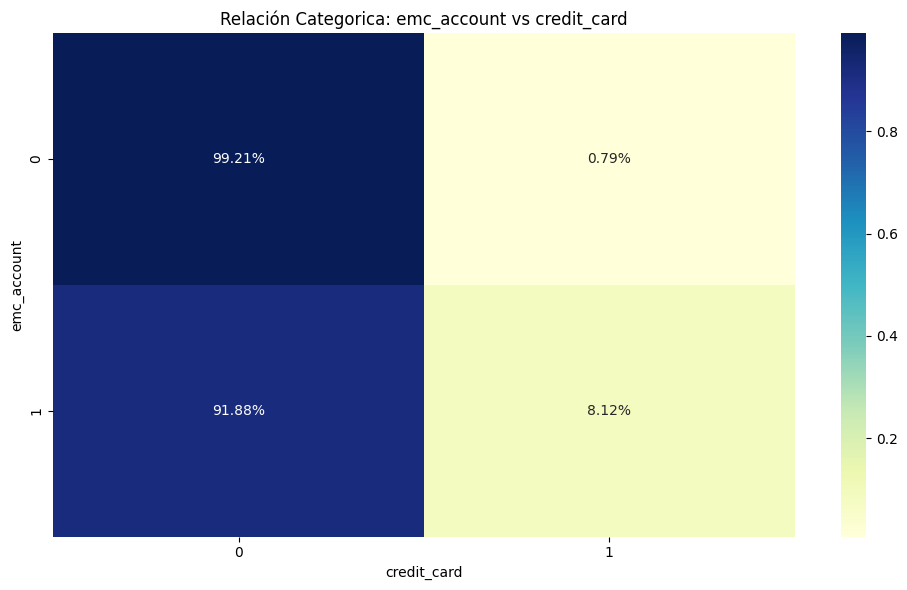

In [ ]:
visualizar_correlacion(df_prod, "emc_account", "credit_card", tipo_grafico='heatmap')

 Generando gráfico tipo: HEATMAP para em_account_p vs credit_card


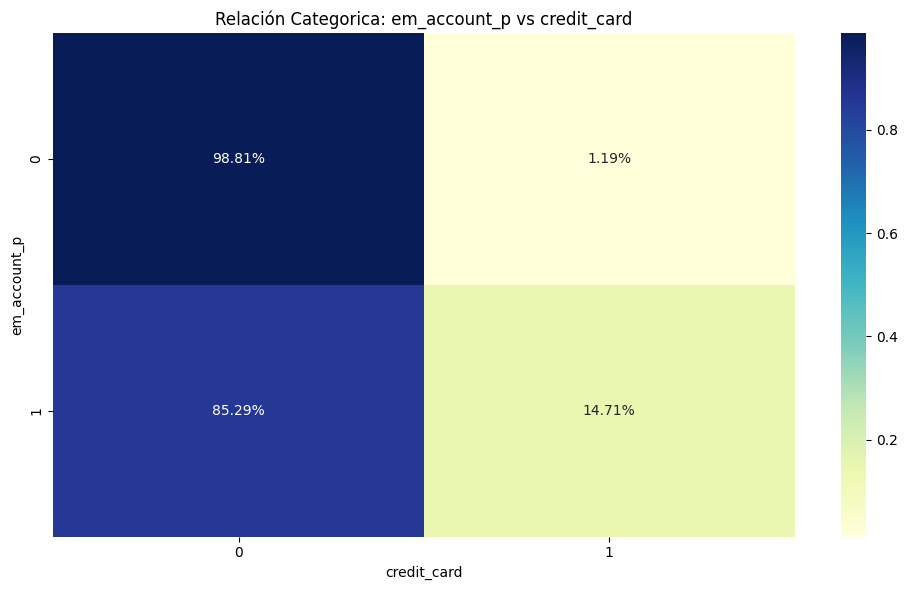

In [ ]:
visualizar_correlacion(df_prod, "em_account_p", "credit_card", tipo_grafico='heatmap')

 Generando gráfico tipo: HEATMAP para emc_account vs mortgage


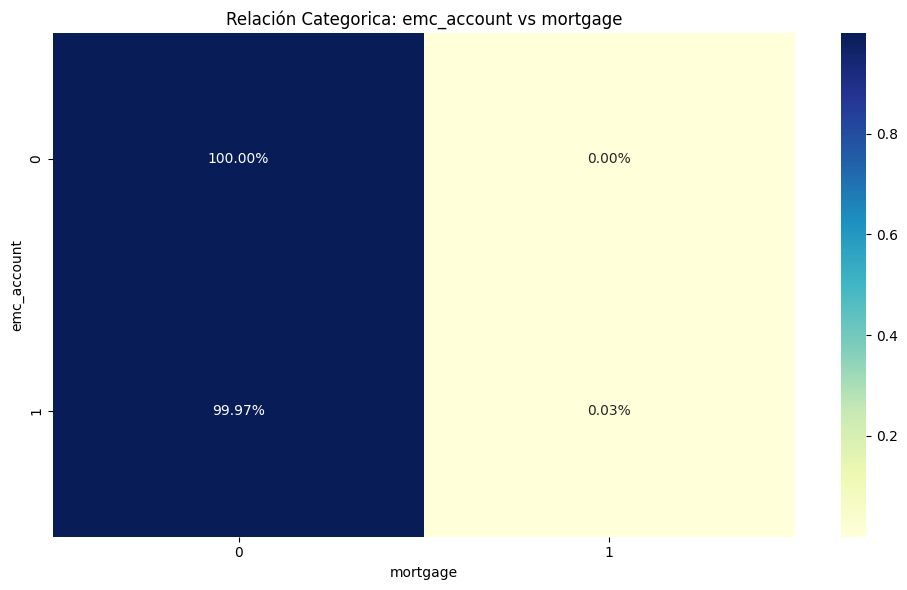

In [ ]:
visualizar_correlacion(df_prod, "emc_account", "mortgage", tipo_grafico='heatmap')

 Generando gráfico tipo: HEATMAP para em_account_p vs mortgage


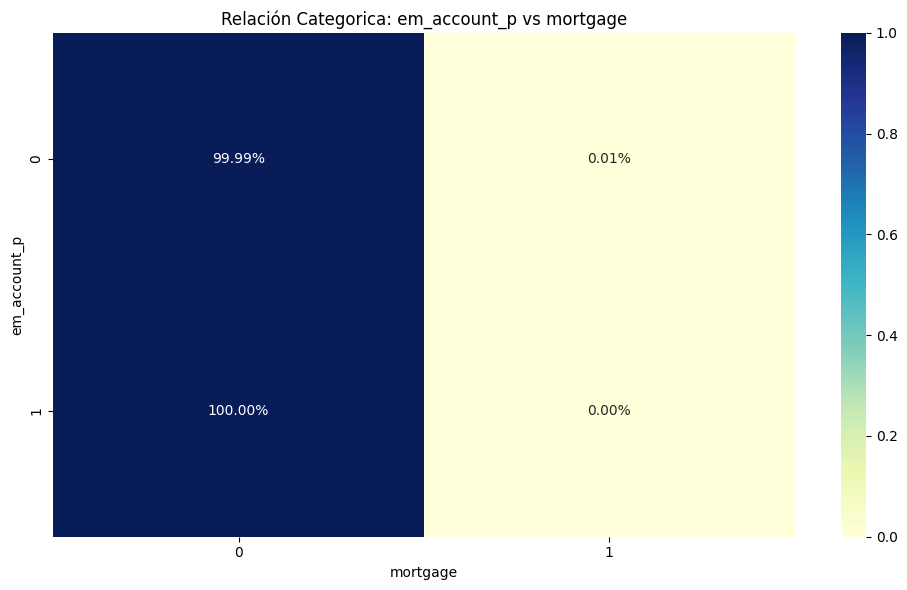

In [ ]:
visualizar_correlacion(df_prod, "em_account_p", "mortgage", tipo_grafico='heatmap')

 Generando gráfico tipo: HEATMAP para emc_account vs short_term_deposit


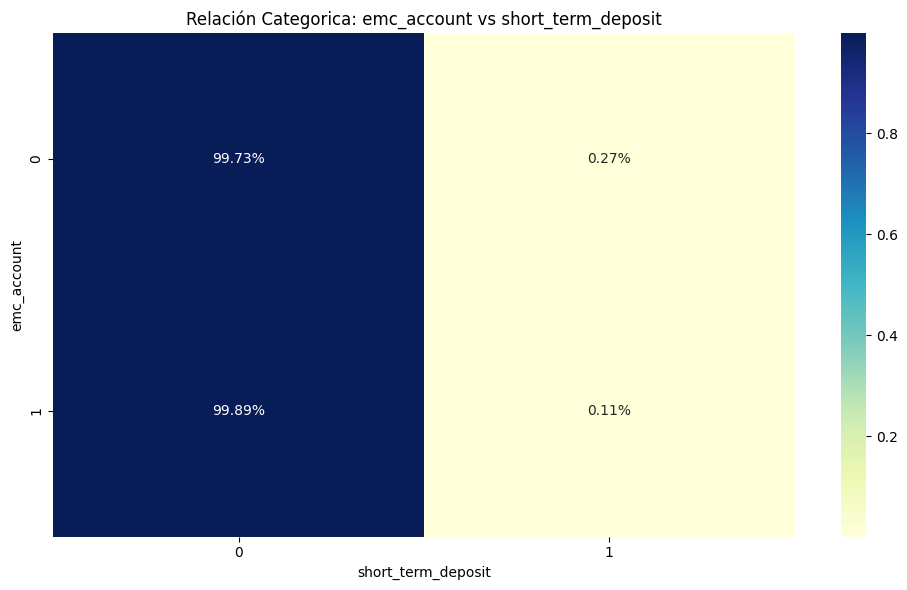

In [ ]:
visualizar_correlacion(df_prod, "emc_account", "short_term_deposit", tipo_grafico='heatmap')

 Generando gráfico tipo: HEATMAP para em_account_p vs short_term_deposit


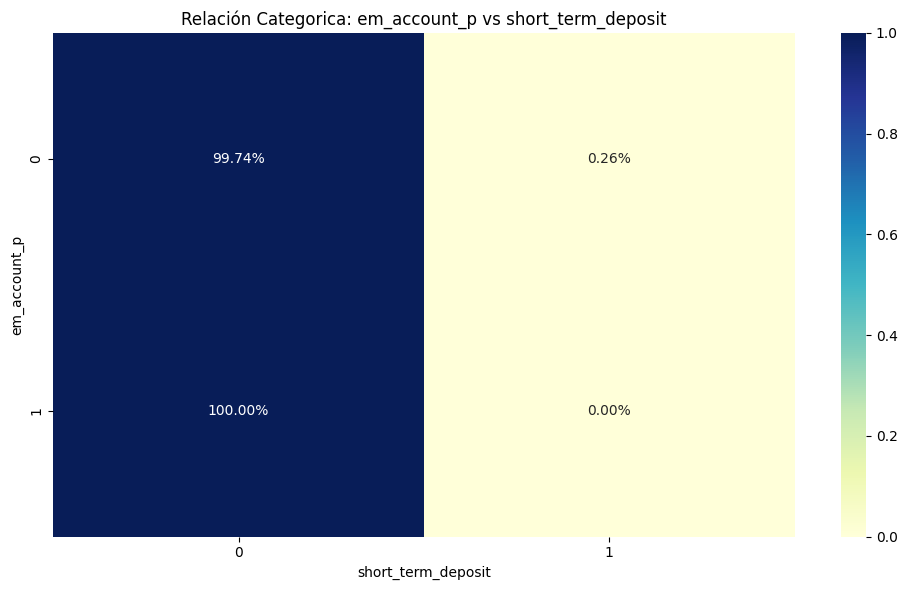

In [ ]:
visualizar_correlacion(df_prod, "em_account_p", "short_term_deposit", tipo_grafico='heatmap')

 Generando gráfico tipo: HEATMAP para emc_account vs long_term_deposit


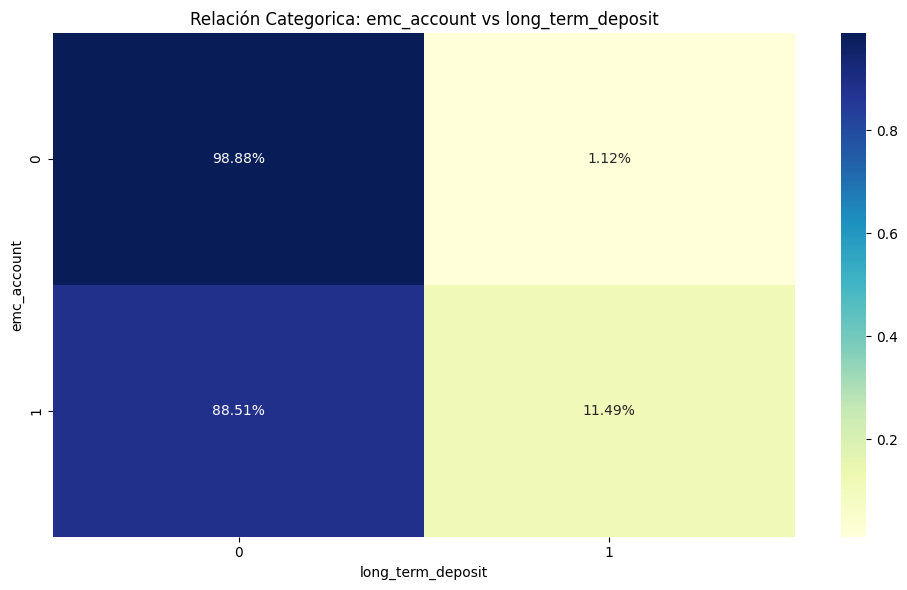

In [ ]:
visualizar_correlacion(df_prod, "emc_account", "long_term_deposit", tipo_grafico='heatmap')

 Generando gráfico tipo: HEATMAP para em_account_p vs long_term_deposit


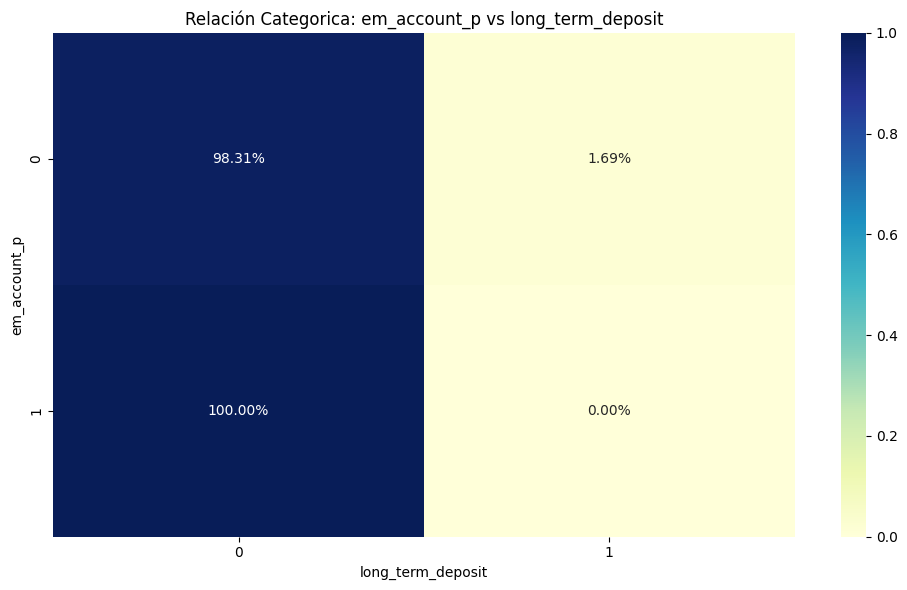

In [ ]:
visualizar_correlacion(df_prod, "em_account_p", "long_term_deposit", tipo_grafico='heatmap')

In [ ]:
df_prod.columns

Index(['pk_cid', 'pk_partition', 'short_term_deposit', 'loans', 'mortgage',
       'funds', 'securities', 'long_term_deposit', 'em_account_pp',
       'credit_card', 'payroll', 'pension_plan', 'payroll_account',
       'emc_account', 'debit_card', 'em_account_p', 'em_acount'],
      dtype='object')

In [ ]:
display(df_prod['long_term_deposit'].value_counts())

long_term_deposit
0    5862264
1     100660
Name: count, dtype: int64

In [ ]:
def analizar_correlaciones_productos(df, cols_productos, agrupar=False, clave_agrupar=None):
    """
    Genera un Mapa de Calor (Heatmap) para múltiples columnas booleanas en base a una agrupación.
    
    Parámetros:
    - df: DataFrame.
    - cols_productos: Lista de las columnas boleanas o binarias a relacionar.
    - agrupar:

        * False (Default): agrupa por el primer pk_ o columna que detecte

        * True: Analiza el perfil general (¿El cliente que contrata X suele contratar Y?)

    - clave_agrupar: (Opcional) Columna específica para agrupar. Si no se proporciona, se busca la primera columna 'pk_'.
    """
    
    # Preparamos los datos
    if agrupar:
        if clave_agrupar is None:
            for col in df.columns:
                if 'pk_' in col and col != 'pk_partition':
                    clave_agrupar = col
                    break
                else:
                    raise ValueError("No se encontró una columna 'pk_' para agrupar. Por favor, especifica 'clave_agrupar'.")
            
            df_analisis = df.groupby(clave_agrupar)[cols_productos].max()
        else:
            df_analisis = df.groupby(clave_agrupar)[cols_productos].max()
        print(f"Agrupando por {clave_agrupar}")
    else:
        df_analisis = df[cols_productos]

    # Cálculo de la Correlación
    # Para variables binarias (0/1), Pearson funciona como el coeficiente Phi
    corr_matrix = df_analisis.corr(method='pearson')
    
    # Diseño del Gráfico
    plt.figure(figsize=(14, 12))
    
    # Heatmap
    # cmap='RdBu_r': Rojo para inversa (si tengo X no tengo Y), Azul para directa (van juntos)
    sns.heatmap(
        corr_matrix, 
        annot=True,     # Muestra el número
        fmt=".2f",      # 2 decimales
        cmap='RdBu',  # Escala de colores Rojo-Azul
        vmin=-0.2, vmax=0.6, # Ajustamos el rango para resaltar correlaciones sutiles (pocas pasan de 0.6)
        center=0,       # El blanco es correlación cero
        linewidths=0.5, # Líneas entre celdas
        cbar_kws={"shrink": .5} # Barra de leyenda más pequeña
    )
    
    plt.title(f"Correlación de booleanos por {clave_agrupar if agrupar else 'relación general'}", fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.show()



In [ ]:
# Columnas de productos a analizar
cols_productos_reales = [
    'loans', 'mortgage', 'funds', 'securities', 'long_term_deposit', 
    'em_account_pp', 'credit_card', 'payroll', 'pension_plan', 
    'payroll_account', 'emc_account', 'debit_card', 'em_account_p', 'em_acount'
]

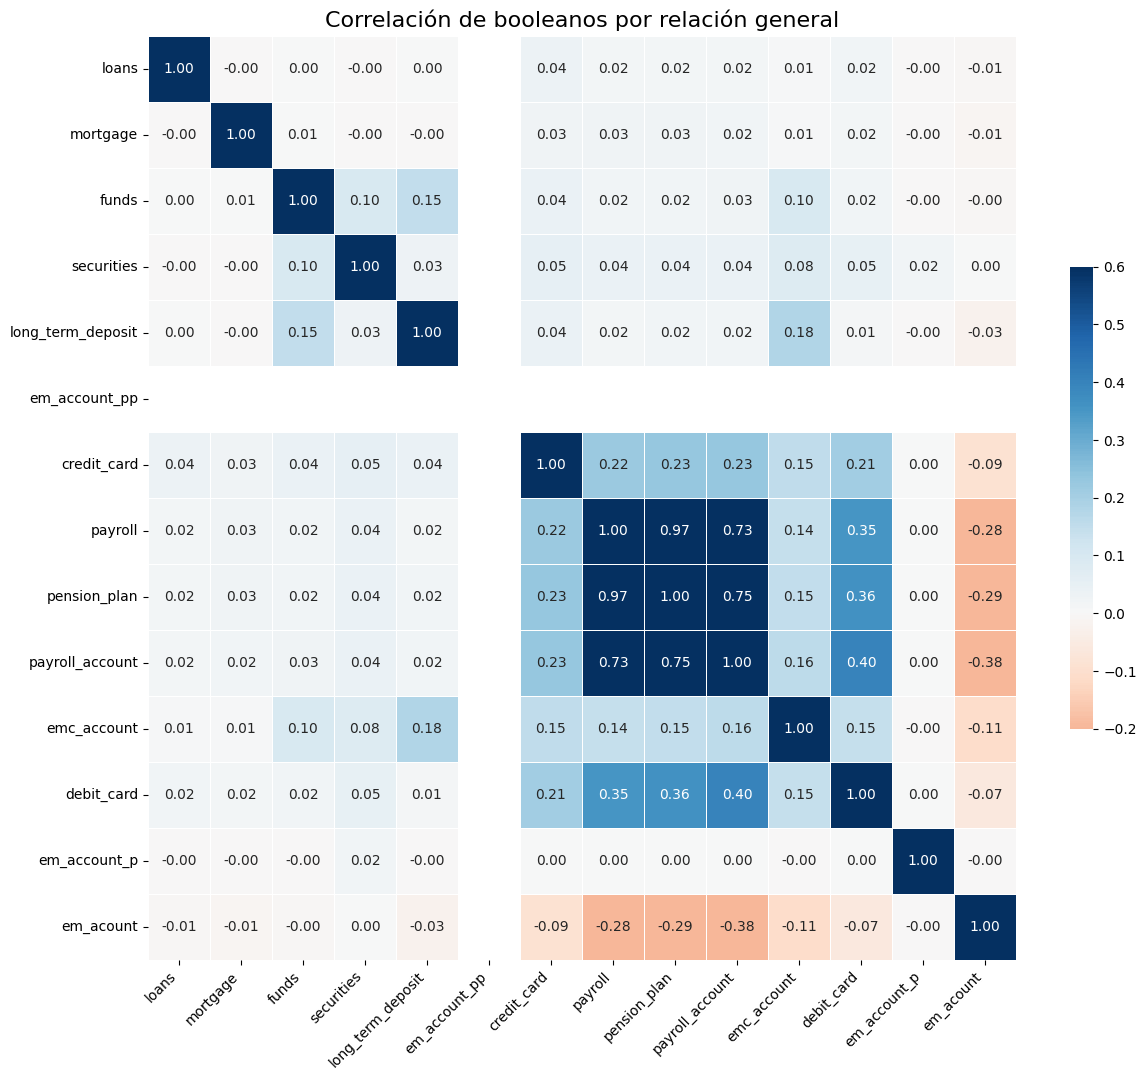

In [ ]:
# Opción A: ¿Qué productos se consumen JUNTOS en el mismo mes?
analizar_correlaciones_productos(df_prod, cols_productos_reales, agrupar=False)

Agrupando por pk_cid


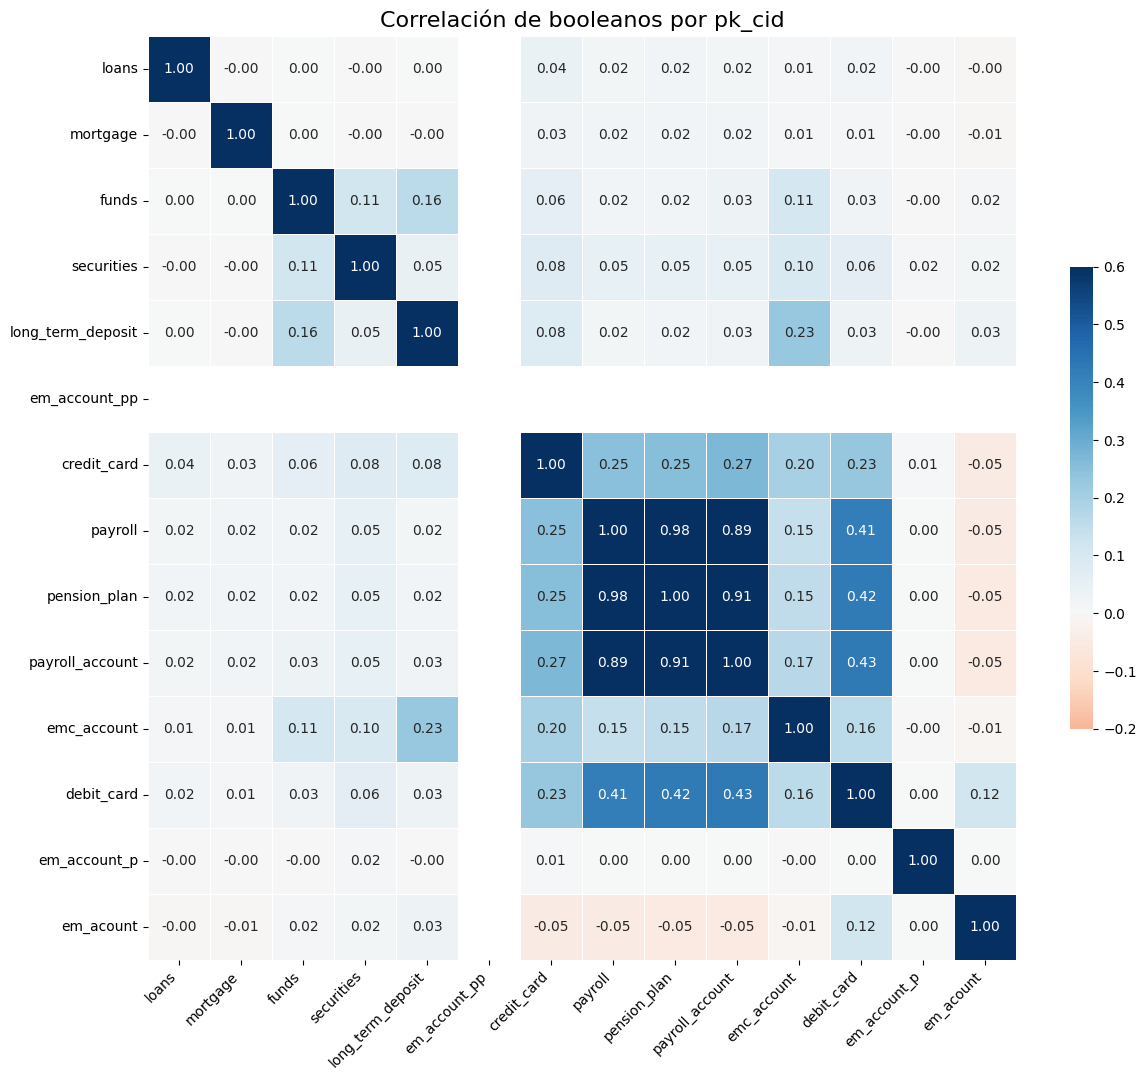

In [ ]:
# Opción B: ¿Qué productos suele tener EL MISMO CLIENTE (aunque sea en meses distintos)?
# Esta responde a tu pregunta: "¿El que tiene emc_account tiende a long_term_deposit?"
analizar_correlaciones_productos(df_prod, cols_productos_reales, agrupar=True, clave_agrupar='pk_cid')

In [ ]:
cols_productos = [
    'loans', 'mortgage', 'funds', 'securities', 'long_term_deposit', 
    'credit_card', 'payroll', 'pension_plan', 'debit_card'
]
analizar_correlaciones_productos(df_prod, cols_productos, agrupar=True, clave_agrupar='emc_acount')
analizar_correlaciones_productos(df_prod, cols_productos, agrupar=False)

KeyError: 'emc_acount'

In [ ]:
# Esta responde a tu pregunta: Hay algún periodo donde se compre más algún producto?"
display(df_prod.groupby('pk_partition')[cols_productos_reales].sum())

,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount
pk_partition,,,,,,,,,,,,,,
2018-01-01,19,15,786,932,4884,0,3325,8145.0,8835.0,13478,15320,24696,2,215293
2018-02-01,19,15,872,965,4956,0,3282,8889.0,9496.0,14246,15827,25448,2,217098
2018-03-01,23,17,969,965,4965,0,3511,9735.0,9882.0,14989,16428,27046,2,218683
2018-04-01,24,17,1084,983,5107,0,3725,9905.0,10560.0,15825,16947,27764,2,219816
2018-05-01,27,18,1145,1012,5356,0,3797,9994.0,10148.0,16697,17569,27911,2,221291
2018-06-01,27,19,1159,1019,5588,0,4002,10946.0,11635.0,15540,17950,28828,2,224328
2018-07-01,28,20,1172,1053,5796,0,4137,11888.0,12779.0,16916,18185,29578,2,234324
2018-08-01,29,20,1219,1133,5923,0,4206,11383.0,12126.0,18118,18333,29205,2,245980
2018-09-01,31,20,1237,1201,6158,0,4289,11850.0,12624.0,18862,18618,31684,2,261210


In [ ]:
def visualizar_evolucion_temporal(df, cols_productos, col_tiempo='pk_partition', modo='linea', normalizar=False):
    """
    Visualiza cómo evoluciona la tenencia o venta de productos a lo largo del tiempo.
    
    Parámetros:
    - df: DataFrame con los datos.
    - cols_productos: Lista de columnas de productos.
    - col_tiempo: Nombre de la columna temporal (default: 'pk_partition').
    - modo: 
        * 'linea': Gráfico de líneas (ideal para ver tendencias).
        * 'area': Gráfico de áreas apiladas (ideal para ver volumen total acumulado).
        * 'heatmap': Mapa de calor (ideal para comparar intensidades).
    - normalizar: 
        * False: Muestra valores absolutos (Cantidad de contratos).
        * True: Muestra valores relativos (Porcentaje del total de ese mes).
    """
    
    # 1. Preparación de datos
    df_temp = df.copy()
    
    # Aseguramos que la fecha sea datetime para que se ordene bien
    if df_temp[col_tiempo].dtype == 'object':
        df_temp[col_tiempo] = pd.to_datetime(df_temp[col_tiempo])
        
    # Agrupamos por fecha y sumamos (para ver volumen de productos activos)
    df_agrupado = df_temp.groupby(col_tiempo)[cols_productos].sum()
    
    # Título dinámico
    titulo = "Evolución Temporal de Productos"
    ylabel = "Cantidad de Contratos"
    
    # 2. Normalización (Opcional)
    if normalizar:
        # Dividimos cada fila por la suma total de esa fila (para obtener %)
        df_agrupado = df_agrupado.div(df_agrupado.sum(axis=1), axis=0) * 100
        titulo += " (Normalizado %)"
        ylabel = "Porcentaje del Portfolio (%)"

    # 3. Visualización
    plt.figure(figsize=(15, 8))
    
    if modo == 'linea':
        # Usamos plot de pandas que gestiona muy bien las fechas en el eje X
        # Iteramos para dar estilos si son muchos productos
        for col in df_agrupado.columns:
            plt.plot(df_agrupado.index, df_agrupado[col], marker='.', label=col, linewidth=2)
        
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.ylabel(ylabel)
        
    elif modo == 'area':
        df_agrupado.plot.area(figsize=(15, 8), alpha=0.7, stacked=True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.ylabel(ylabel)

    elif modo == 'heatmap':
        # Transponemos para que los Productos estén en el eje Y y el Tiempo en el X
        # Es más fácil de leer así
        sns.heatmap(
            df_agrupado.T, 
            cmap='YlGnBu', # Amarillo a Verde a Azul (bueno para volumen)
            annot=False,   # False para no saturar si hay muchos meses
            linewidths=0.5,
            fmt=".1f" if normalizar else ".0f"
        )
        plt.ylabel("Productos")
        plt.xlabel("Fecha (Partition)")
    
    plt.title(titulo, fontsize=16)
    plt.tight_layout()
    plt.show()



In [ ]:
# --- EJEMPLOS DE USO ---

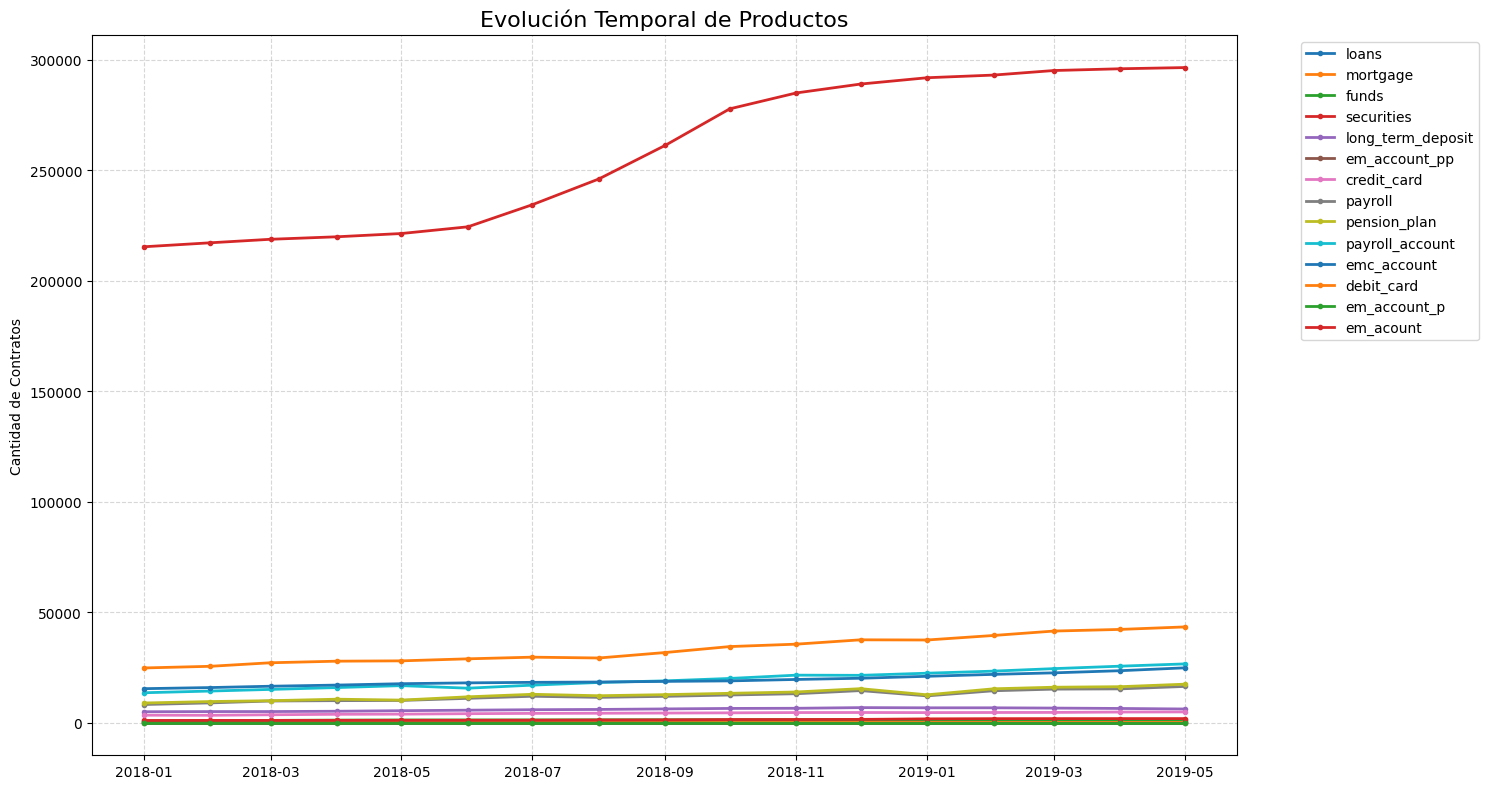

In [ ]:
# 1. Ver la tendencia absoluta (¿Suben o bajan las ventas?)
visualizar_evolucion_temporal(df_prod, cols_productos_reales, modo='linea', normalizar=False)

<Figure size 1500x800 with 0 Axes>

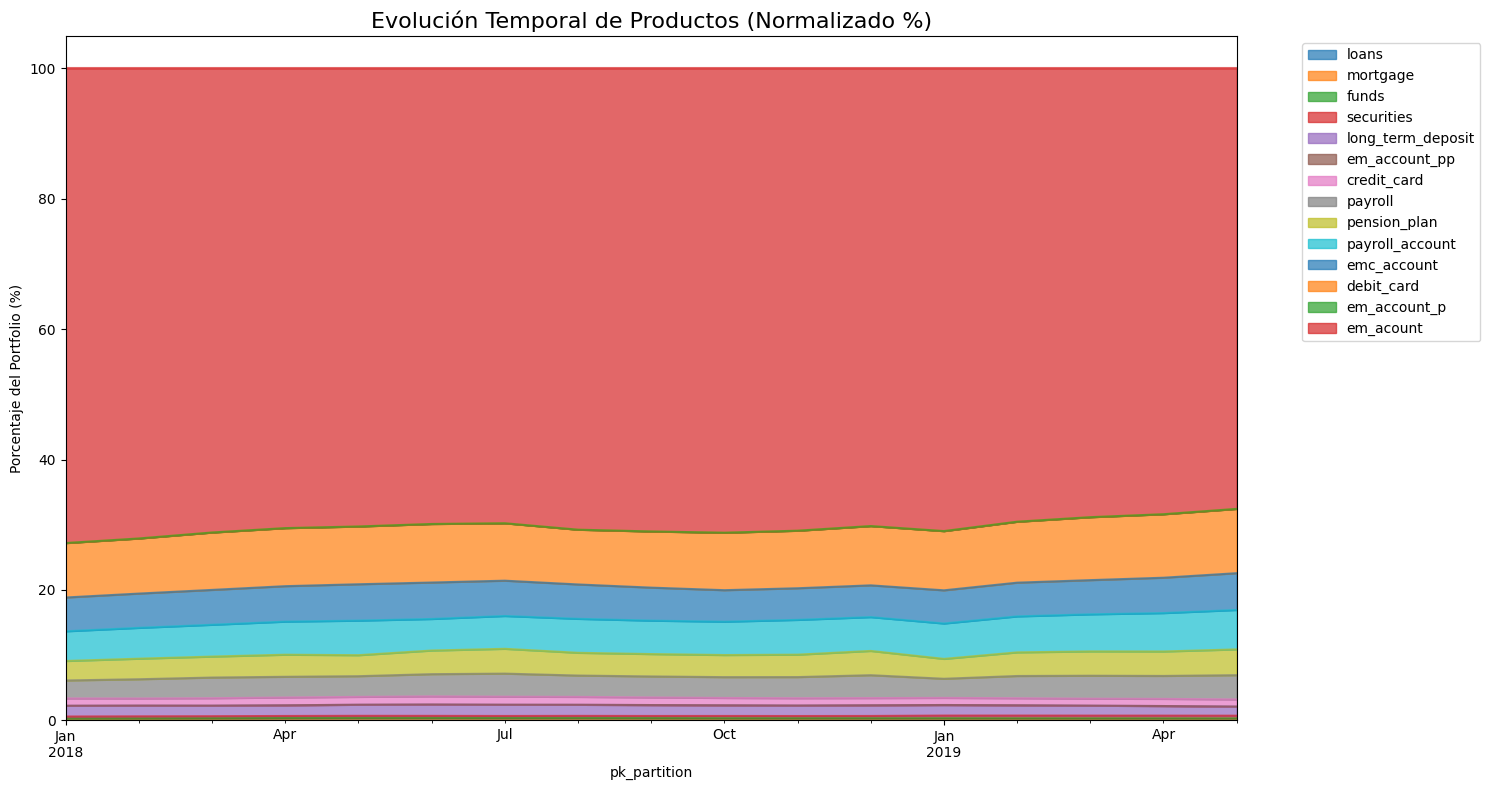

In [ ]:
# 2. Ver el "Share" de productos (¿Qué productos dominan la cartera?)
# El modo 'area' normalizado es genial para ver cómo un producto "come terreno" a otro
visualizar_evolucion_temporal(df_prod, cols_productos_reales, modo='area', normalizar=True)

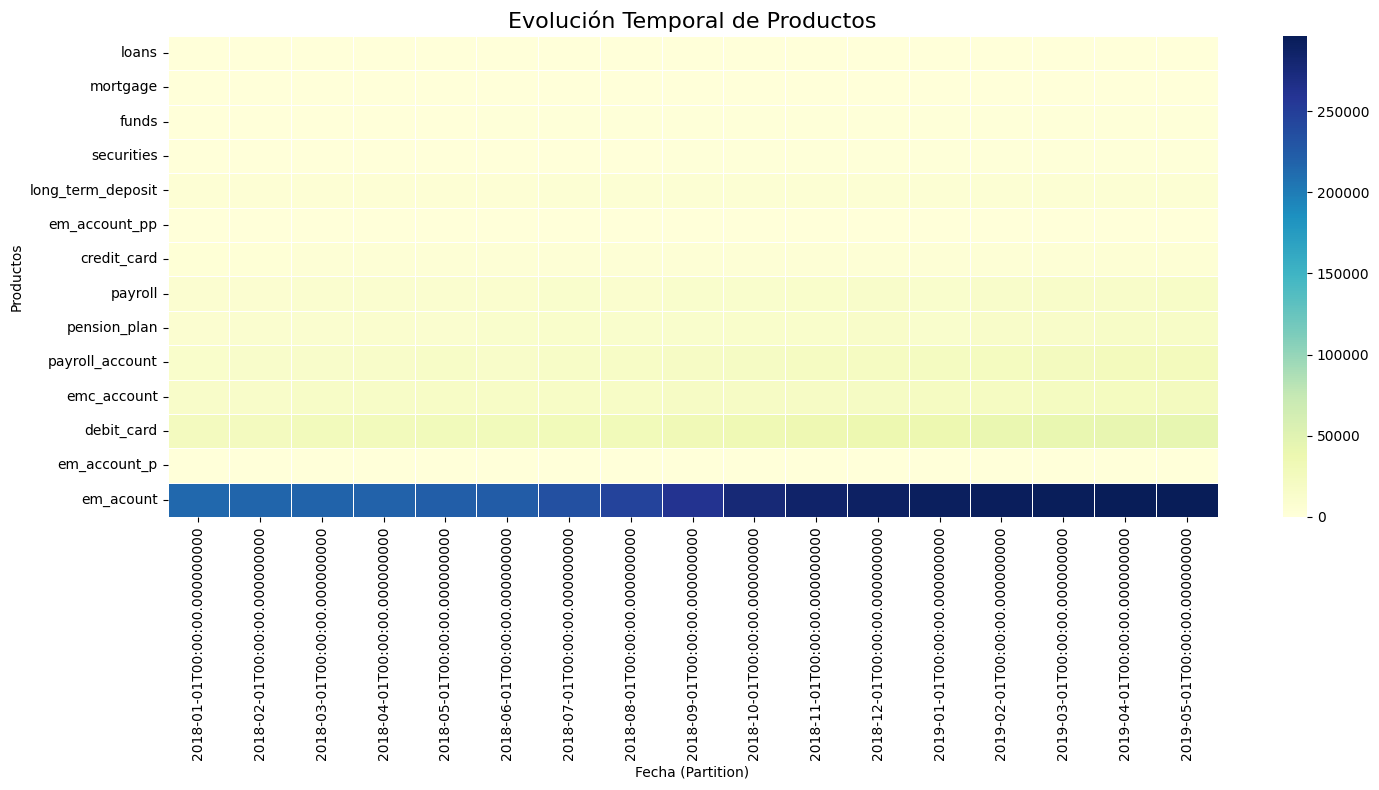

In [ ]:
# 3. Mapa de calor (Tu petición específica de colormap)
# Aquí verás claramente cuándo se lanzó un producto (pasa de claro a oscuro)
visualizar_evolucion_temporal(df_prod, cols_productos_reales, modo='heatmap', normalizar=False)

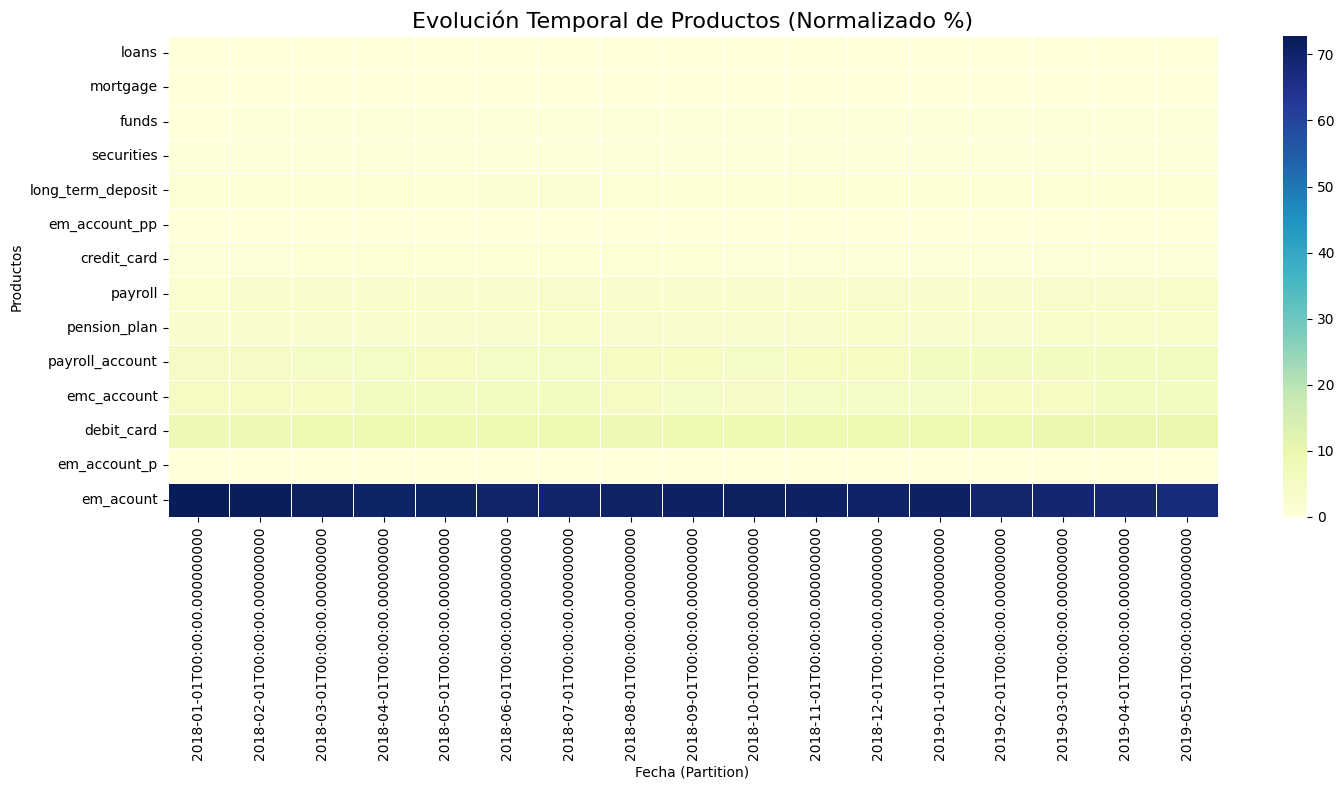

In [ ]:
# 3. Mapa de calor (Tu petición específica de colormap)
# Aquí verás claramente cuándo se lanzó un producto (pasa de claro a oscuro)
visualizar_evolucion_temporal(df_prod, cols_productos_reales, modo='heatmap', normalizar=True)

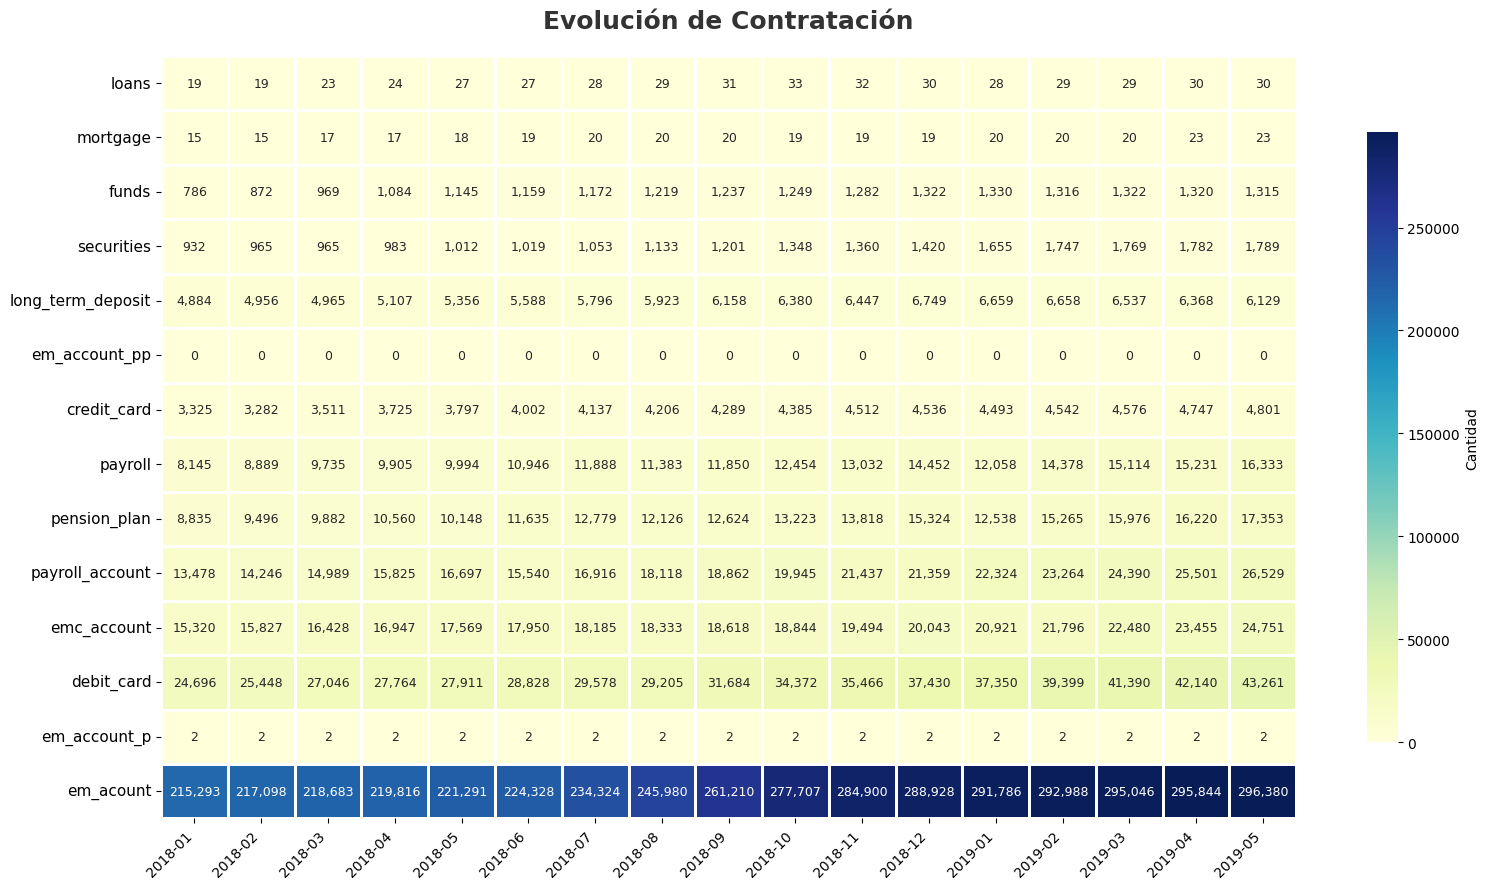

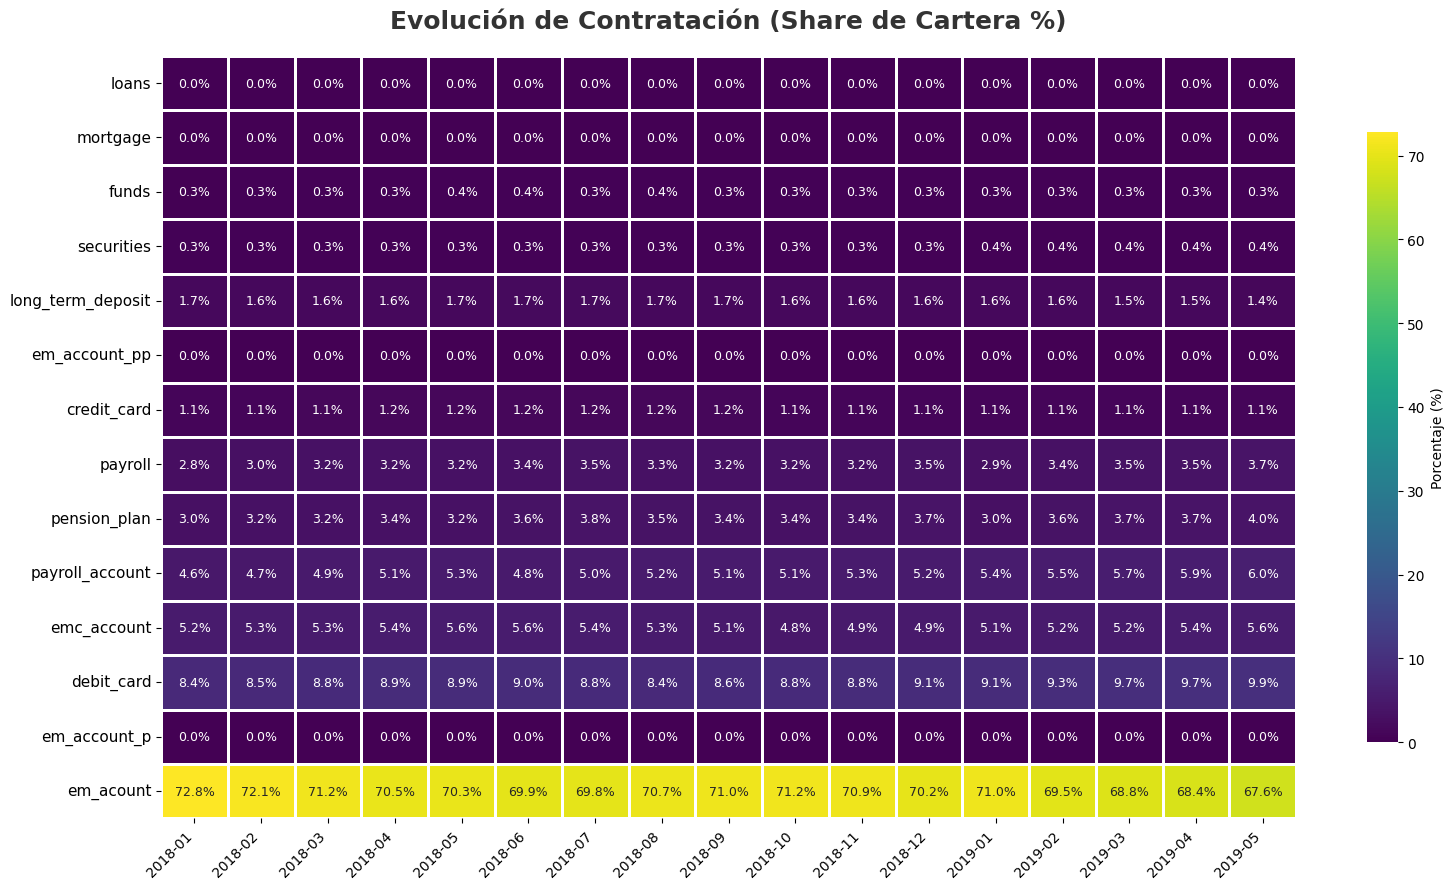

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

def visualizar_evolucion_premium(df, cols_productos, col_tiempo='pk_partition', modo='linea', normalizar=False):
    """
    Visualización mejorada con estética 'Business Intelligence'.
    """
    
    # 1. Preparación de datos
    df_temp = df.copy()
    if df_temp[col_tiempo].dtype == 'object':
        df_temp[col_tiempo] = pd.to_datetime(df_temp[col_tiempo])
        
    # Agrupamos y ordenamos
    df_agrupado = df_temp.groupby(col_tiempo)[cols_productos].sum()
    
    # Formato de fechas para que se lean bien (Año-Mes)
    df_agrupado.index = df_agrupado.index.strftime('%Y-%m')
    
    # Configuración de Etiquetas y Títulos
    titulo = "Evolución de Contratación"
    unidad_cbar = "Cantidad"
    
    # 2. Normalización (Cálculo del Share %)
    if normalizar:
        # Dividimos por el total del mes para ver la cuota de cada producto
        df_agrupado = df_agrupado.div(df_agrupado.sum(axis=1), axis=0) * 100
        titulo += " (Share de Cartera %)"
        unidad_cbar = "Porcentaje (%)"

    # 3. Visualización
    plt.figure(figsize=(16, 9)) # Formato panorámico
    
    if modo == 'heatmap':
        # Transponemos: Productos en filas (Y), Fechas en columnas (X)
        data_plot = df_agrupado.T
        
        # Paleta: 'Blues' o 'YlGnBu' para absoluto, 'RdYlGn' (semáforo) o 'viridis' para %
        cmap = 'viridis' if normalizar else 'YlGnBu'
        
        # Formato de texto dentro de las celdas
        fmt = ".1f" if normalizar else ",.0f" # 1 decimal o enteros con comas
        
        # DIBUJO DEL HEATMAP
        ax = sns.heatmap(
            data_plot, 
            cmap=cmap, 
            annot=True,             # Mostrar números
            fmt=fmt,                # Formato numérico base
            linewidths=1,           # Líneas blancas separadoras (Estilo Waffle)
            linecolor='white',      
            cbar_kws={'label': unidad_cbar, 'shrink': 0.8},
            annot_kws={"size": 9}   # Tamaño de letra cómodo
        )
        
        # TRUCO: Añadir el símbolo '%' manualmente si está normalizado
        if normalizar:
            for t in ax.texts:
                t.set_text(t.get_text() + "%")

        # AJUSTE DE ETIQUETAS (Lo que pediste)
        plt.yticks(rotation=0, fontsize=11)  # Productos rectos
        plt.xticks(rotation=45, ha='right')  # Fechas inclinadas ligeramente
        plt.xlabel("") # Quitamos la etiqueta 'pk_partition' que sobra
        plt.ylabel("") # Quitamos 'Productos' que es obvio
        
    elif modo == 'linea':
        # Estilo de líneas limpio
        sns.set_style("whitegrid")
        sns.lineplot(data=df_agrupado, dashes=False, palette="tab10", linewidth=2.5)
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Productos")
        plt.ylabel(unidad_cbar)
        plt.xticks(rotation=45)

    elif modo == 'area':
        # Área apilada
        df_agrupado.plot.area(figsize=(16, 9), alpha=0.8, stacked=True, colormap="tab20")
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Productos")
        plt.ylabel(unidad_cbar)
    
    plt.title(titulo, fontsize=18, pad=20, fontweight='bold', color='#333333')
    plt.tight_layout()
    plt.show()

# --- PRUEBA LA DIFERENCIA ---

# Opción A: Absoluto (Limpio y con separadores)
visualizar_evolucion_premium(df_prod, cols_productos_reales, modo='heatmap', normalizar=False)

# Opción B: Tu petición (Normalizado, con % y etiquetas rectas)
visualizar_evolucion_premium(df_prod, cols_productos_reales, modo='heatmap', normalizar=True)

Entrenar el modelo balanceando las clases. Cuando separemos quien ha comprado algo un mes prepararemos un modelo que separe la misma cantidad de compradores y misma cantidad de no compradores. Esto se podrá preparar por cada producto o por todos los productos